<a href="https://colab.research.google.com/github/anna030608/DS/blob/master/DATATHON/Depression%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0단계 : 기본 전처리

## 데이터 불러오기

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
print(train_df.shape)
print(test_df.shape)

(140700, 20)
(93800, 19)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

## columns 설명
- id
- Name
- Gender (Female/Male)
- Age
- City
- Working Professional or Student
- Profession: 직업
- Academic Pressure: 학업 스트레스 수준 (1~5)
- Work Pressure: 업무 스트레스 수준 (1~5)
- CGPA: 학점(성취도 평가)
- Study Satisfaction: 학업 만족도 (1~5)
- Job Satisfaction: 직무 만족도 (1~5)
- Sleep Duration: 수면시간
- Dietary Habits: 식습관 (Healthy/Unhealthy 등)
- Degree: 학위
- Have you ever had suicidal thoughts ?: 자살 생각 경험 여부
- Work/Study Hours: 주당 공부/근무 시간
- Financial Stress: 경제적 스트레스 (1~5)
- Family History of Mental Illness: 가족력 여부
- Depression: 타겟 변수 (0: 우울X / 1: 우울O)
  - 우울감 경험 여부/위험 가능성
  | 구분             | 의미                            |
| -------------- | ----------------------------- |
| Depression = 1 | 설문 기반 우울 위험 또는 우울감 경험 가능성이 있다 |
| Depression = 0 | 그렇지 않다 (우울 위험 낮음)             |
| 실제 진단 여부       | 아님 (임상 진단 아님)                 |


In [ ]:
train_df.head(3)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1


In [ ]:
train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


In [ ]:
print(train_df.isnull().sum())

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64


In [ ]:
print(train_df.isnull().mean())

id                                       0.000000
Name                                     0.000000
Gender                                   0.000000
Age                                      0.000000
City                                     0.000000
Working Professional or Student          0.000000
Profession                               0.260341
Academic Pressure                        0.801727
Work Pressure                            0.198422
CGPA                                     0.801720
Study Satisfaction                       0.801727
Job Satisfaction                         0.198365
Sleep Duration                           0.000000
Dietary Habits                           0.000028
Degree                                   0.000014
Have you ever had suicidal thoughts ?    0.000000
Work/Study Hours                         0.000000
Financial Stress                         0.000028
Family History of Mental Illness         0.000000
Depression                               0.000000


In [ ]:
# 원본 복사 - EDA용
df = train_df.copy()

In [ ]:
df['Dietary Habits'].value_counts()

,count
Dietary Habits,
Moderate,49705
Unhealthy,46227
Healthy,44741
Yes,2
More Healthy,2
No,2
Pratham,1
Gender,1
BSc,1


In [ ]:
# 1. Dietary Habits 이상 카테고리 제거
valid_diet = ['Healthy', 'Moderate', 'Unhealthy']
df = df[df['Dietary Habits'].isin(valid_diet)]

<Axes: xlabel='Age', ylabel='Count'>

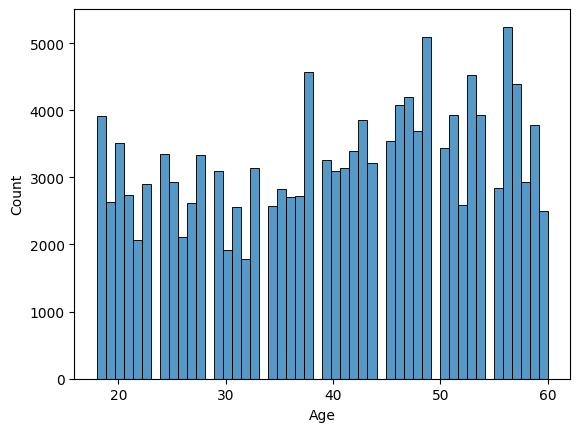

In [ ]:
sns.histplot(x='Age', data=df)

In [ ]:
# 2. Age Group 생성 - EDA용
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[17,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

In [ ]:
print(df['Academic Pressure'].unique())
print(df['Work Pressure'].unique())

[nan  5.  2.  3.  4.  1.]
[ 5.  4. nan  1.  2.  3.]


In [ ]:
# 3. Pressure Level 묶기 - EDA용
df['Academic Pressure Level'] = np.where(
    df['Academic Pressure'] >= 4, 'High (4-5)', 'Low/Medium (1-3)'
)

df['Work Pressure Level'] = np.where(
    df['Work Pressure'] >= 4, 'High (4-5)', 'Low/Medium (1-3)'
)

In [ ]:
df['Sleep Duration'].value_counts()

,count
Sleep Duration,
Less than 5 hours,38774
7-8 hours,36960
More than 8 hours,32722
5-6 hours,32138
3-4 hours,12
6-7 hours,8
4-5 hours,7
4-6 hours,5
2-3 hours,5


In [ ]:
# 4. Sleep Duration 이상 카테고리 제거
valid_sleep = [
    'Less than 5 hours',
    '5-6 hours',
    '7-8 hours',
    'More than 8 hours'
]
df = df[df['Sleep Duration'].isin(valid_sleep)]

In [ ]:
print("EDA용 데이터 shape:", df.shape)

EDA용 데이터 shape: (140594, 23)


# 1단계 : EDA를 통한 위험 요인 구조 탐색

### 1-1. Depression
- 전체 우울 비율
- 클래스 불균형 정도 확인

In [ ]:
GROUP_COL = 'Working Professional or Student'
TARGET = 'Depression'

# 집단 이름 통일
# 'Student', 'Working Professional'
df[GROUP_COL] = df[GROUP_COL].astype(str).str.strip()

# 집단별 데이터 분리
student_df = df[df[GROUP_COL] == 'Student'].copy()
working_df = df[df[GROUP_COL] == 'Working Professional'].copy()

print("=== 전체 / 집단별 데이터 크기 ===")
print("Total:", df.shape)
print("Student:", student_df.shape)
print("Working:", working_df.shape)

=== 전체 / 집단별 데이터 크기 ===
Total: (140594, 23)
Student: (27871, 23)
Working: (112723, 23)


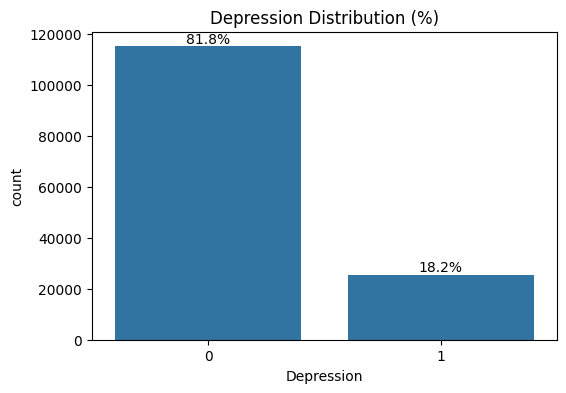

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Depression', data=df)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title("Depression Distribution (%)")
plt.show()

0 (비우울): 81.8%

1 (우울): 18.2%

- 18%면 약 5명 중 1명은 우울한 상태 -> 꽤 높은 수치

### 1-2. Student/Working 별 우울 비율

In [ ]:
group_rate = (
    df.groupby(GROUP_COL)[TARGET]
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={'mean':'Depression Rate', 'count':'N'})
)
group_rate['Depression Rate (%)'] = group_rate['Depression Rate'] * 100

print("\n=== 집단별 우울 비율(%) + N ===")
print(group_rate[[GROUP_COL, 'Depression Rate (%)', 'N']])


=== 집단별 우울 비율(%) + N ===
  Working Professional or Student  Depression Rate (%)       N
0                         Student            58.551900   27871
1            Working Professional             8.185552  112723


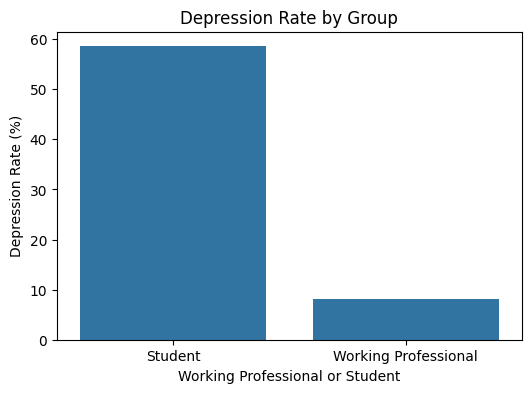

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=group_rate, x=GROUP_COL, y='Depression Rate (%)')
plt.title('Depression Rate by Group')
plt.ylabel('Depression Rate (%)')
plt.show()

| 그룹                   | 비우울 (0) | 우울 (1)     |
| -------------------- | ------- | ---------- |
| Student              | 41.45%  | **58.55%** |
| Working Professional | 91.82%  | **8.18%**  |

- 우울증의 중심 집단은 "학생"
- 전체 우울증 평균 18%는 직장인이 80% 이상 차지하기 때문에 낮아진 것 -> 실제로는 학생 집단에서 우울증일 확률이 매우 높다.

### 1-3. Age (연령)


=== 집단별 Age 기술통계 ===
                                    count       mean        std   min   25%  \
Working Professional or Student                                               
Student                           27871.0  25.821068   4.905752  18.0  21.0   
Working Professional             112723.0  43.990623  10.949974  18.0  38.0   

                                  50%   75%   max  
Working Professional or Student                    
Student                          25.0  30.0  59.0  
Working Professional             46.0  53.0  60.0  


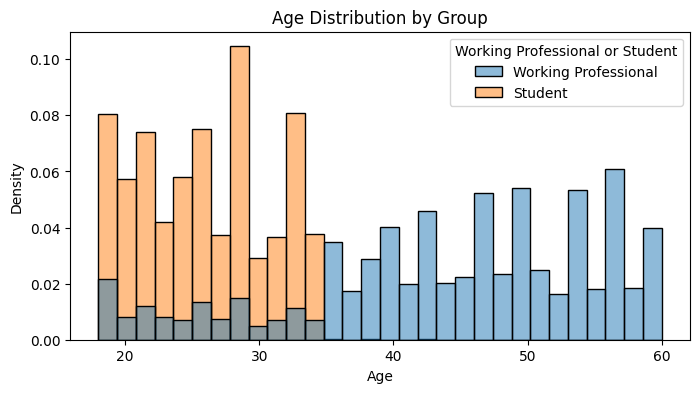


=== Age Group × Group 분포 ===
Working Professional or Student  Student  Working Professional
Age Group                                                     
18-25                              13945                 10104
26-35                              13887                 12052
36-45                                 28                 33436
46-55                                  8                 38293
56-65                                  3                 18838


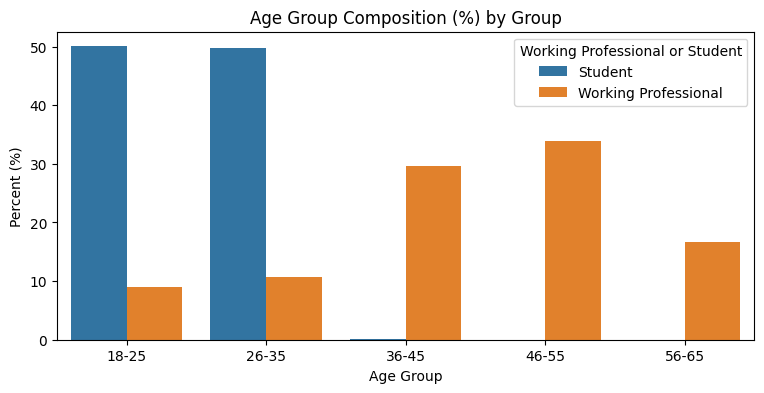

In [ ]:
print("\n=== 집단별 Age 기술통계 ===")
print(df.groupby(GROUP_COL)['Age'].describe())

# Age 히스토그램 - (집단별)
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', hue=GROUP_COL, bins=30, stat='density', common_norm=False)
plt.title('Age Distribution by Group')
plt.show()

# Age Group
if 'Age Group' in df.columns:
    age_group_cnt = pd.crosstab(df['Age Group'], df[GROUP_COL])
    print("\n=== Age Group × Group 분포 ===")
    print(age_group_cnt)

    age_group_prop = age_group_cnt.div(age_group_cnt.sum(axis=0), axis=1) * 100
    age_group_prop = age_group_prop.reset_index().melt(id_vars='Age Group', var_name=GROUP_COL, value_name='Percent')

    plt.figure(figsize=(9,4))
    sns.barplot(data=age_group_prop, x='Age Group', y='Percent', hue=GROUP_COL)
    plt.title('Age Group Composition (%) by Group')
    plt.ylabel('Percent (%)')
    plt.show()

### 1-4. 집단별 공통변수 분포/우울비율 차이


==================== Financial Stress ====================

=== 분포(Count) ===
Working Professional or Student  Student  Working Professional
Financial Stress                                              
1.0                                 5113                 22076
2.0                                 5056                 26375
3.0                                 5220                 20748
4.0                                 5770                 21972
5.0                                 6709                 21551

=== 우울 비율(%) + N ===
  Working Professional or Student  Financial Stress  Depression Rate (%)  \
0                         Student               1.0            31.859965   
1                         Student               2.0            42.978639   
2                         Student               3.0            58.946360   
3                         Student               4.0            69.098787   
4                         Student               5.0            81.263974   
5 

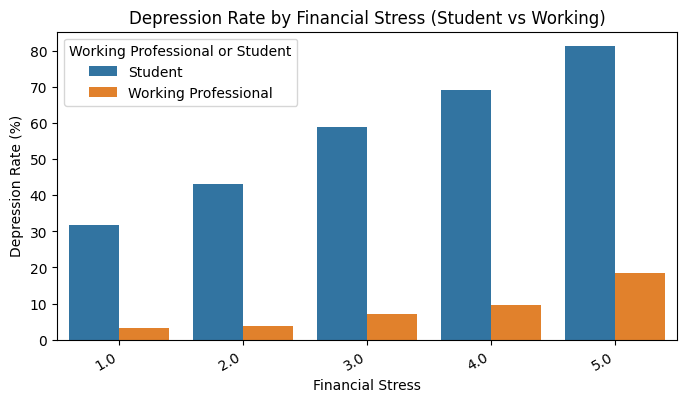


==================== Work/Study Hours ====================

=== 분포(Count) ===
Working Professional or Student  Student  Working Professional
Work/Study Hours                                              
0.0                                 1698                 10362
1.0                                 1147                  8647
2.0                                 1588                  9001
3.0                                 1468                  7996
4.0                                 1608                  7446
5.0                                 1296                  8035
6.0                                 2245                  8175
7.0                                 1999                  7868
8.0                                 2507                  6393
9.0                                 2025                 10678
10.0                                4231                  9959
11.0                                2891                  9931
12.0                                316

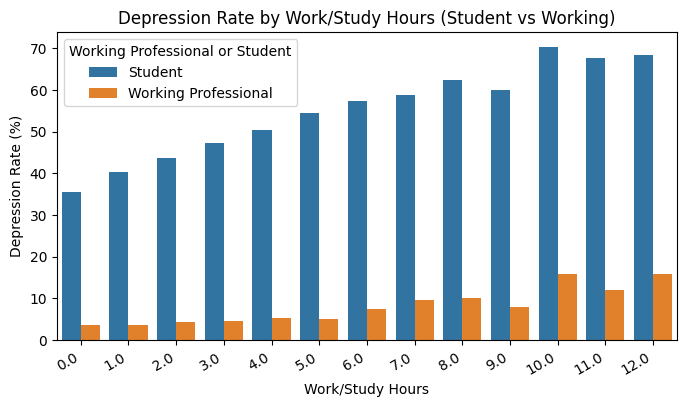


==================== Sleep Duration ====================

=== 분포(Count) ===
Working Professional or Student  Student  Working Professional
Sleep Duration                                                
5-6 hours                           6180                 25958
7-8 hours                           7343                 29617
Less than 5 hours                   8305                 30469
More than 8 hours                   6043                 26679

=== 우울 비율(%) + N ===
  Working Professional or Student     Sleep Duration  Depression Rate (%)  \
0                         Student          5-6 hours            56.860841   
1                         Student          7-8 hours            59.498842   
2                         Student  Less than 5 hours            64.527393   
3                         Student  More than 8 hours            50.918418   
4            Working Professional          5-6 hours             6.953540   
5            Working Professional          7-8 hours         

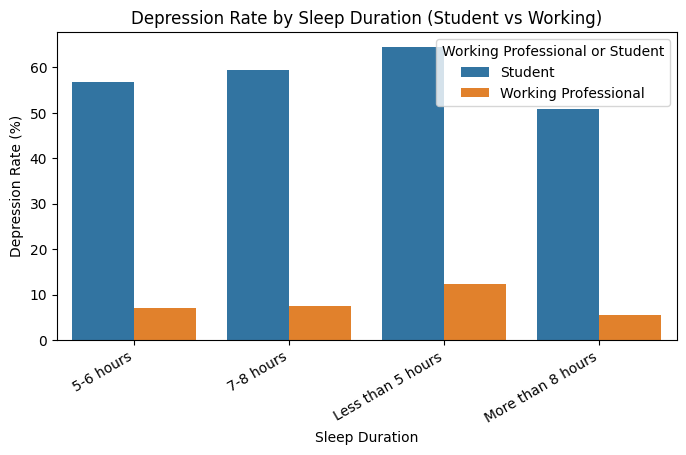


==================== Dietary Habits ====================

=== 분포(Count) ===
Working Professional or Student  Student  Working Professional
Dietary Habits                                                
Healthy                             7648                 37075
Moderate                            9914                 39756
Unhealthy                          10309                 35892

=== 우울 비율(%) + N ===
  Working Professional or Student Dietary Habits  Depression Rate (%)      N
0                         Student        Healthy            45.384414   7648
1                         Student       Moderate            56.031874   9914
2                         Student      Unhealthy            70.744010  10309
3            Working Professional        Healthy             4.873904  37075
4            Working Professional       Moderate             6.723513  39756
5            Working Professional      Unhealthy            13.225788  35892


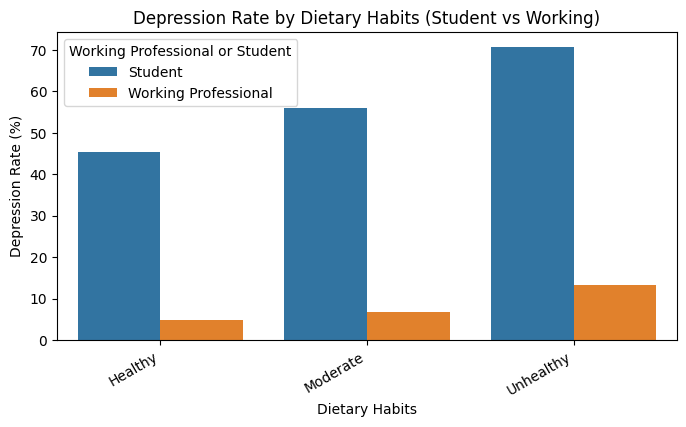

In [ ]:
common_vars = [
    'Financial Stress',
    'Work/Study Hours',
    'Sleep Duration',
    'Dietary Habits'
]

for var in common_vars:

    if var not in df.columns:
        continue

    print(f"\n==================== {var} ====================")

    tmp = df[[GROUP_COL, var, TARGET]].dropna()

    # 분포
    print("\n=== 분포(Count) ===")
    print(pd.crosstab(tmp[var], tmp[GROUP_COL]))

    # 우울 비율 계산
    summary = (
        tmp.groupby([GROUP_COL, var])[TARGET]
           .agg(['mean','count'])
           .reset_index()
           .rename(columns={'mean':'Depression Rate','count':'N'})
    )
    summary['Depression Rate (%)'] = summary['Depression Rate'] * 100

    print("\n=== 우울 비율(%) + N ===")
    print(summary[[GROUP_COL, var, 'Depression Rate (%)', 'N']])


    # 시각화
    plt.figure(figsize=(8,4))

    sns.barplot(
        data=summary,
        x=var,
        y='Depression Rate (%)',
        hue=GROUP_COL
    )

    plt.title(f'Depression Rate by {var} (Student vs Working)')
    plt.ylabel('Depression Rate (%)')
    plt.xticks(rotation=30, ha='right')
    plt.show()

- 거의 동일한 패턴 -> 공통 요인

## 1. 집단 분리 정당성 확인

 ### 1-1. financial Stress


=== Financial Stress × Group 우울 비율 ===
  Working Professional or Student  Financial Stress  Depression Rate (%)  \
0                         Student               1.0            31.859965   
1                         Student               2.0            42.978639   
2                         Student               3.0            58.946360   
3                         Student               4.0            69.098787   
4                         Student               5.0            81.263974   
5            Working Professional               1.0             3.080268   
6            Working Professional               2.0             3.848341   
7            Working Professional               3.0             6.964527   
8            Working Professional               4.0             9.666849   
9            Working Professional               5.0            18.388938   

       N  
0   5113  
1   5056  
2   5220  
3   5770  
4   6709  
5  22076  
6  26375  
7  20748  
8  21972  
9  21551  


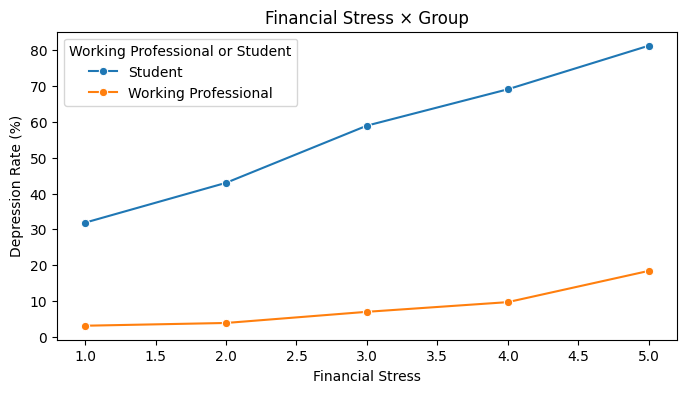


=== Working Professional 내부 Chi-square ===
Chi2: 4516.4013755860215
p-value: 0.0

=== Student 내부 Chi-square ===
Chi2: 3697.1969759531667
p-value: 0.0


In [ ]:
var = 'Financial Stress'

tmp = df[[GROUP_COL, var, TARGET]].dropna()

# 우울 비율 계산
summary = (
    tmp.groupby([GROUP_COL, var])[TARGET]
       .agg(['mean','count'])
       .reset_index()
       .rename(columns={'mean':'Depression Rate','count':'N'})
)

summary['Depression Rate (%)'] = summary['Depression Rate'] * 100

print("\n=== Financial Stress × Group 우울 비율 ===")
print(summary[[GROUP_COL, var, 'Depression Rate (%)','N']])

# 시각화
plt.figure(figsize=(8,4))
sns.lineplot(
    data=summary,
    x=var,
    y='Depression Rate (%)',
    hue=GROUP_COL,
    marker='o'
)
plt.title('Financial Stress × Group')
plt.ylabel('Depression Rate (%)')
plt.show()

# 카이제곱 (집단별 따로)
for g in tmp[GROUP_COL].unique():
    sub = tmp[tmp[GROUP_COL] == g]
    cont = pd.crosstab(sub[var], sub[TARGET])
    chi2, p, dof, _ = chi2_contingency(cont)

    print(f"\n=== {g} 내부 Chi-square ===")
    print("Chi2:", chi2)
    print("p-value:", p)

### 1-2. 집단별 Pressure

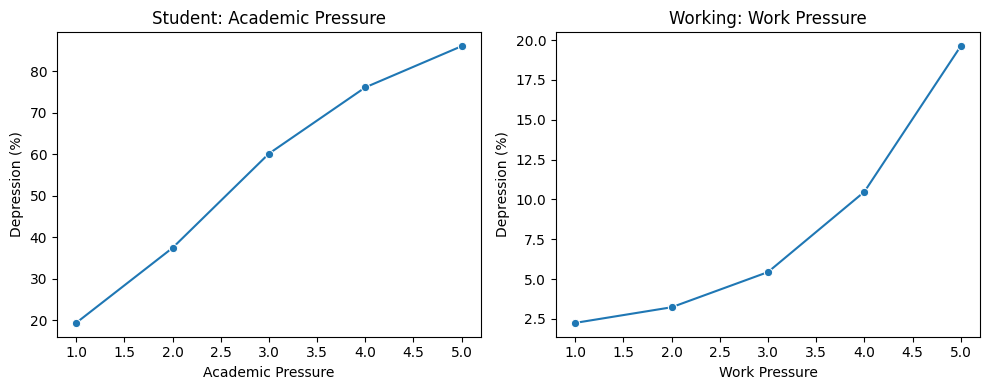

In [ ]:
# Student
student_tmp = student_df[['Academic Pressure', TARGET]].dropna()

student_summary = (
    student_tmp.groupby('Academic Pressure')[TARGET]
               .agg(['mean','count'])
               .reset_index()
)

student_summary['Depression (%)'] = student_summary['mean']*100

# Working
working_tmp = working_df[['Work Pressure', TARGET]].dropna()

working_summary = (
    working_tmp.groupby('Work Pressure')[TARGET]
               .agg(['mean','count'])
               .reset_index()
)

working_summary['Depression (%)'] = working_summary['mean']*100


# 시각화 비교
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.lineplot(data=student_summary,
             x='Academic Pressure',
             y='Depression (%)',
             marker='o')
plt.title('Student: Academic Pressure')

plt.subplot(1,2,2)
sns.lineplot(data=working_summary,
             x='Work Pressure',
             y='Depression (%)',
             marker='o')
plt.title('Working: Work Pressure')

plt.tight_layout()
plt.show()

### 1-3. 집단별 Satisfaction

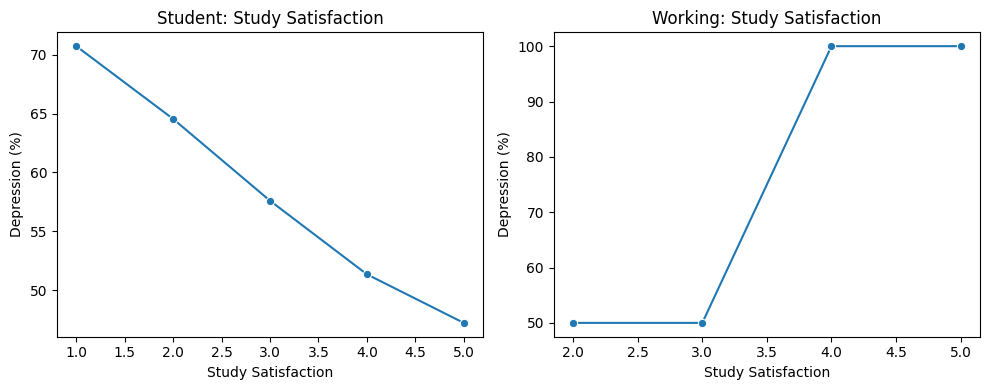

In [ ]:
# Student
student_tmp = student_df[['Study Satisfaction', TARGET]].dropna()

student_summary = (
    student_tmp.groupby('Study Satisfaction')[TARGET]
               .agg(['mean','count'])
               .reset_index()
)

student_summary['Depression (%)'] = student_summary['mean']*100

# Working
working_tmp = working_df[['Study Satisfaction', TARGET]].dropna()

working_summary = (
    working_tmp.groupby('Study Satisfaction')[TARGET]
               .agg(['mean','count'])
               .reset_index()
)

working_summary['Depression (%)'] = working_summary['mean']*100


# 시각화 비교
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.lineplot(data=student_summary,
             x='Study Satisfaction',
             y='Depression (%)',
             marker='o')
plt.title('Student: Study Satisfaction')

plt.subplot(1,2,2)
sns.lineplot(data=working_summary,
             x='Study Satisfaction',
             y='Depression (%)',
             marker='o')
plt.title('Working: Study Satisfaction')

plt.tight_layout()
plt.show()

=> 학생과 직장인은 우울함 리스크 구조가 다르다.

### 1-4. Age Group

/tmp/ipykernel_2943/3575478931.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp_age.groupby([GROUP_COL,'Age Group'])[TARGET]


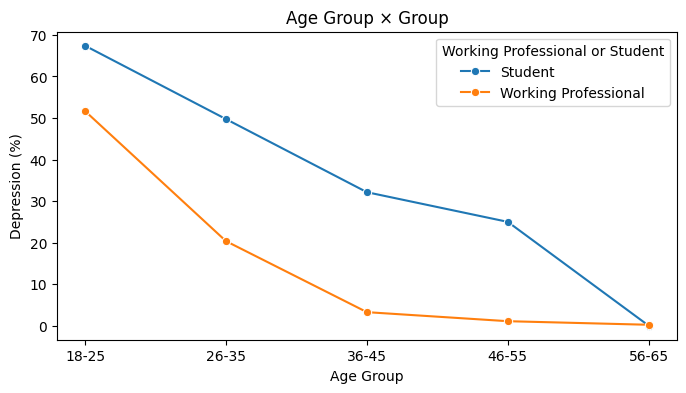

In [ ]:
tmp_age = df[[GROUP_COL, 'Age Group', TARGET]].dropna()

summary_age = (
    tmp_age.groupby([GROUP_COL,'Age Group'])[TARGET]
           .mean()
           .reset_index()
)

summary_age['Depression (%)'] = summary_age[TARGET]*100

plt.figure(figsize=(8,4))
sns.lineplot(data=summary_age,
             x='Age Group',
             y='Depression (%)',
             hue=GROUP_COL,
             marker='o')
plt.title('Age Group × Group')
plt.show()

### 1-5. 내부 단순 검정

In [ ]:
def simple_chi_test(data, var, group_name):
    tmp = data[[var, 'Depression']].dropna()
    cont = pd.crosstab(tmp[var], tmp['Depression'])

    chi2, p, dof, expected = chi2_contingency(cont)

    # Cramér's V
    n = cont.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(cont.shape)-1)))

    print(f"\n=== {group_name} | {var} ===")
    print("Chi2:", chi2)
    print("p-value:", p)
    print("Cramér's V:", cramers_v)

In [ ]:
## Financial Stress

# Student
simple_chi_test(student_df, 'Financial Stress', 'Student')

# Working
simple_chi_test(working_df, 'Financial Stress', 'Working')


=== Student | Financial Stress ===
Chi2: 3697.1969759531667
p-value: 0.0
Cramér's V: 0.36423644088676344

=== Working | Financial Stress ===
Chi2: 4516.4013755860215
p-value: 0.0
Cramér's V: 0.20016674299495082


In [ ]:
## Pressure

# Student
simple_chi_test(student_df, 'Academic Pressure', 'Student')

# Working
simple_chi_test(working_df, 'Work Pressure', 'Working')


=== Student | Academic Pressure ===
Chi2: 6422.314430674215
p-value: 0.0
Cramér's V: 0.4801087690016633

=== Working | Work Pressure ===
Chi2: 6083.6213977453335
p-value: 0.0
Cramér's V: 0.23233431111462827


In [ ]:
def simple_ttest(data, var, group_name):
    tmp = data[[var, 'Depression']].dropna()

    g0 = tmp[tmp['Depression']==0][var]
    g1 = tmp[tmp['Depression']==1][var]

    t_stat, p = ttest_ind(g0, g1)

    print(f"\n=== {group_name} | {var} ===")
    print("t-statistic:", t_stat)
    print("p-value:", p)

In [ ]:
## Age

# Student
simple_ttest(student_df, 'Age', 'Student')

# Working
simple_ttest(working_df, 'Age', 'Working')


=== Student | Age ===
t-statistic: 38.86105933032853
p-value: 0.0

=== Working | Age ===
t-statistic: 179.26244133864685
p-value: 0.0


- 각 집단내부에서 해당 3개 컬럼이 유의함을 확인함.

## 2. Student 집단 내부 구조 탐색
Student 집단에서 우울과 가장 강하게 관련된 요인은 무엇인가?

- Academic Pressure
- Financial Stress
- Study Satisfaction
- Work/Study Hours
- Sleep Duration
- Dietary Habits
- CGPA

### 2-1. Student 내부 기본 위험 요인 랭킹

In [ ]:
TARGET = 'Depression'

student_vars = [
    'Academic Pressure',
    'Study Satisfaction',
    'Financial Stress',
    'Sleep Duration',
    'Work/Study Hours',
    'Age',
    'Gender',
    'CGPA',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Dietary Habits'
]

def cramers_v(cont_table):
    chi2 = chi2_contingency(cont_table)[0]
    n = cont_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(cont_table.shape)-1)))

def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x) + (ny-1)*np.var(y)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std


Student 내부 분석: Academic Pressure

=== 평균 비교 ===
Depression
0    2.362432
1    3.694146
Name: Academic Pressure, dtype: float64

=== t-test ===
t-statistic: -90.13575445787261
p-value: 0.0
Cohen's d: -1.0962026597504089


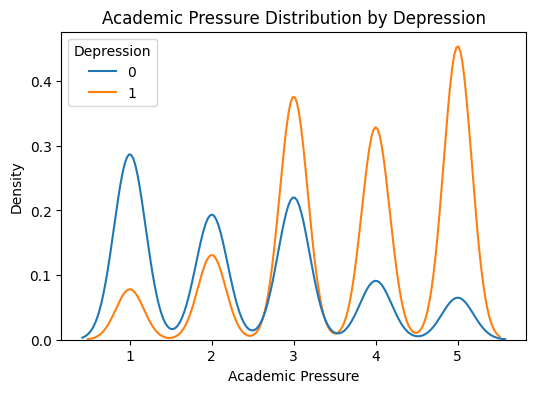


Student 내부 분석: Study Satisfaction

=== 평균 비교 ===
Depression
0    3.216401
1    2.752161
Name: Study Satisfaction, dtype: float64

=== t-test ===
t-statistic: 28.47091853924042
p-value: 8.856741857837517e-176
Cohen's d: 0.3462542100778023


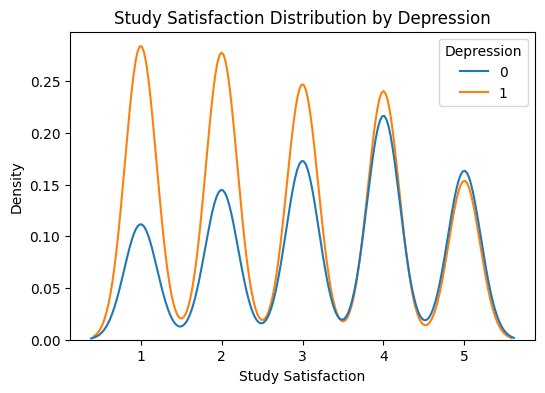


Student 내부 분석: Financial Stress

=== 평균 비교 ===
Depression
0    2.519134
1    3.579728
Name: Financial Stress, dtype: float64

=== t-test ===
t-statistic: -65.14046481001792
p-value: 0.0
Cohen's d: -0.7921271702357705


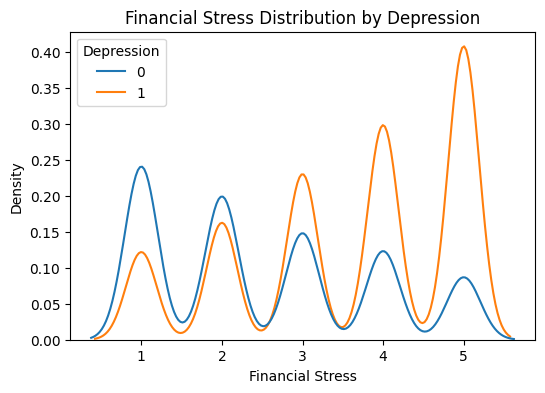


Student 내부 분석: Sleep Duration

=== 분포(Count) ===
Sleep Duration
Less than 5 hours    8305
7-8 hours            7343
5-6 hours            6180
More than 8 hours    6043
Name: count, dtype: int64

=== 우울 비율(%) + N ===
      Sleep Duration  Depression Rate (%)     N
0          5-6 hours            56.860841  6180
1          7-8 hours            59.498842  7343
2  Less than 5 hours            64.527393  8305
3  More than 8 hours            50.918418  6043

=== Chi-square test ===
Chi2: 277.2819305465542
p-value: 8.202618856247307e-60
Cramér's V: 0.09974347826413939


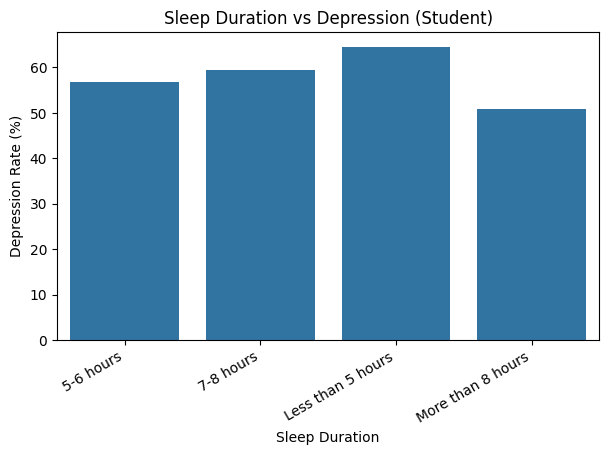


Student 내부 분석: Work/Study Hours

=== 평균 비교 ===
Depression
0    6.239093
1    7.809057
Name: Work/Study Hours, dtype: float64

=== t-test ===
t-statistic: -35.61218787792802
p-value: 1.1213164402716809e-271
Cohen's d: -0.4330274800219934


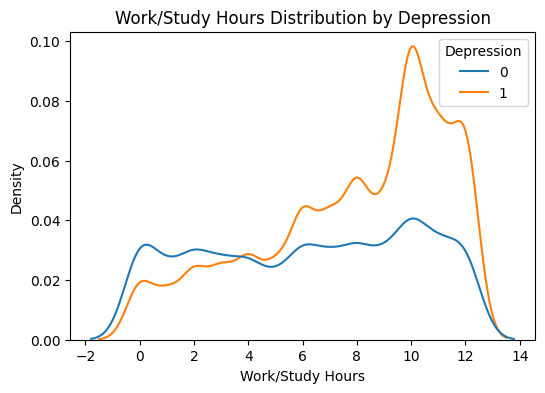


Student 내부 분석: Age

=== 평균 비교 ===
Depression
0    27.143006
1    24.885287
Name: Age, dtype: float64

=== t-test ===
t-statistic: 38.86105933032853
p-value: 0.0
Cohen's d: 0.472532074001872


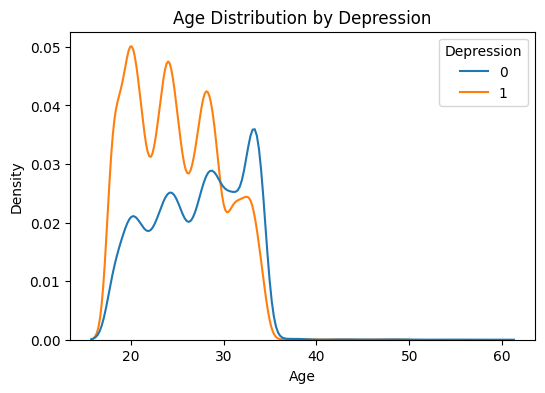


Student 내부 분석: Gender

=== 분포(Count) ===
Gender
Male      15530
Female    12341
Name: count, dtype: int64

=== 우울 비율(%) + N ===
   Gender  Depression Rate (%)      N
0  Female            58.447452  12341
1    Male            58.634900  15530

=== Chi-square test ===
Chi2: 0.09198663726609856
p-value: 0.7616665885805456
Cramér's V: 0.001816712045434258


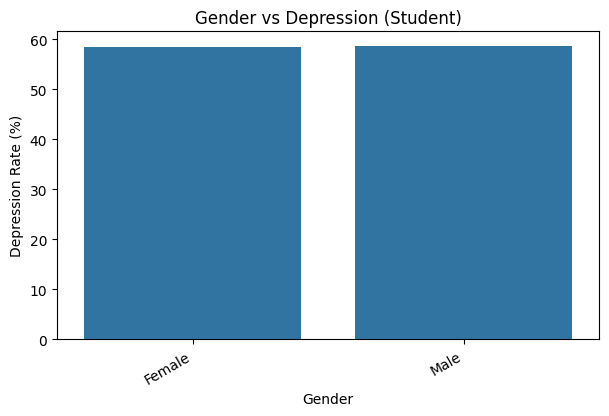


Student 내부 분석: CGPA

=== 평균 비교 ===
Depression
0    7.621335
1    7.685092
Name: CGPA, dtype: float64

=== t-test ===
t-statistic: -3.580668395997701
p-value: 0.00034329923981260216
Cohen's d: -0.04354695333139202


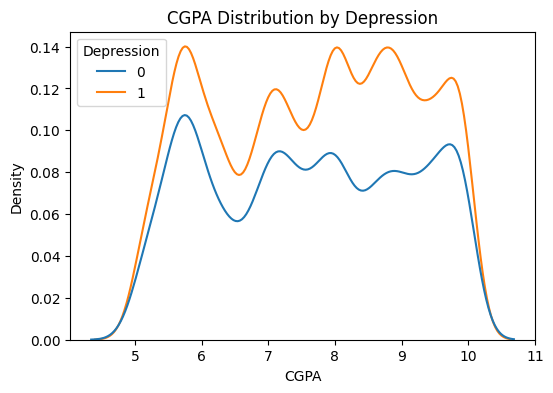


Student 내부 분석: Have you ever had suicidal thoughts ?

=== 분포(Count) ===
Have you ever had suicidal thoughts ?
Yes    17635
No     10236
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Have you ever had suicidal thoughts ?  Depression Rate (%)      N
0                                    No            23.221962  10236
1                                   Yes            79.058690  17635

=== Chi-square test ===
Chi2: 8318.162466040521
p-value: 0.0
Cramér's V: 0.5463078281058983


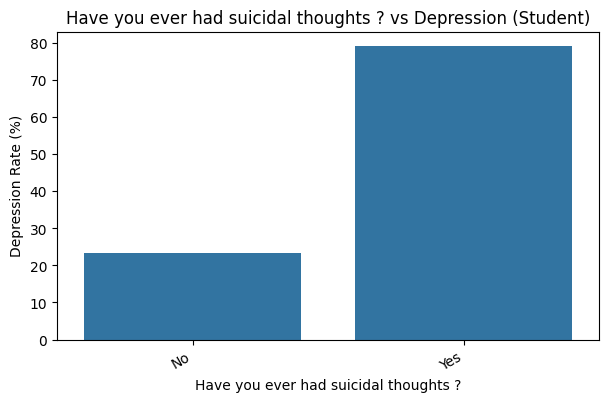


Student 내부 분석: Family History of Mental Illness

=== 분포(Count) ===
Family History of Mental Illness
No     14379
Yes    13492
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Family History of Mental Illness  Depression Rate (%)      N
0                               No            56.012240  14379
1                              Yes            61.258524  13492

=== Chi-square test ===
Chi2: 78.72637803819917
p-value: 7.133665422214235e-19
Cramér's V: 0.05314762475218242


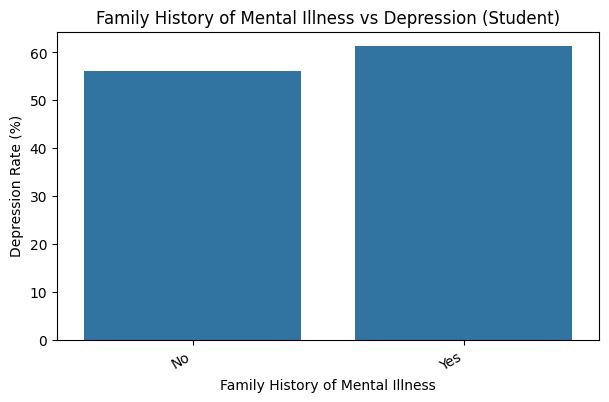


Student 내부 분석: Dietary Habits

=== 분포(Count) ===
Dietary Habits
Unhealthy    10309
Moderate      9914
Healthy       7648
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Dietary Habits  Depression Rate (%)      N
0        Healthy            45.384414   7648
1       Moderate            56.031874   9914
2      Unhealthy            70.744010  10309

=== Chi-square test ===
Chi2: 1203.7741996422708
p-value: 4.015631191170944e-262
Cramér's V: 0.2078242585728984


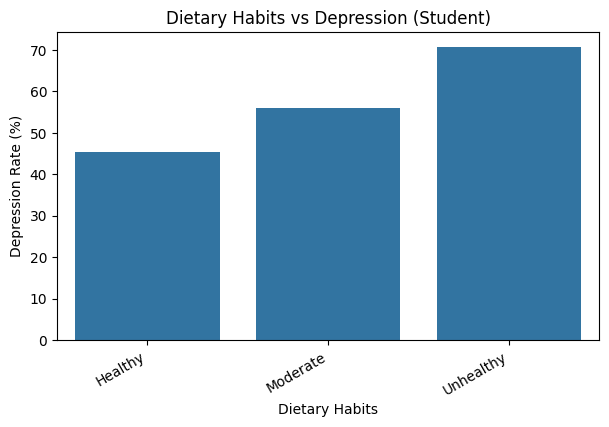

In [ ]:
for var in student_vars:

    if var not in student_df.columns:
        continue

    print("\n===================================================")
    print(f"Student 내부 분석: {var}")
    print("===================================================")

    tmp = student_df[[var, TARGET]].dropna()

    # 연속형 변수 처리
    if tmp[var].dtype in ['int64','float64']:

        print("\n=== 평균 비교 ===")
        print(tmp.groupby(TARGET)[var].mean())

        g0 = tmp[tmp[TARGET]==0][var]
        g1 = tmp[tmp[TARGET]==1][var]

        t_stat, p = ttest_ind(g0, g1)
        effect = cohen_d(g0, g1)

        print("\n=== t-test ===")
        print("t-statistic:", t_stat)
        print("p-value:", p)
        print("Cohen's d:", effect)

        # 시각화
        plt.figure(figsize=(6,4))
        sns.kdeplot(data=tmp, x=var, hue=TARGET)
        plt.title(f'{var} Distribution by Depression')
        plt.show()

    # 범주형 변수 처리
    else:

        print("\n=== 분포(Count) ===")
        print(tmp[var].value_counts())

        summary = (
            tmp.groupby(var)[TARGET]
               .agg(['mean','count'])
               .reset_index()
               .rename(columns={'mean':'Depression Rate','count':'N'})
        )
        summary['Depression Rate (%)'] = summary['Depression Rate']*100

        print("\n=== 우울 비율(%) + N ===")
        print(summary[[var,'Depression Rate (%)','N']])

        # 카이제곱
        cont = pd.crosstab(tmp[var], tmp[TARGET])
        chi2, p, dof, _ = chi2_contingency(cont)
        effect = cramers_v(cont)

        print("\n=== Chi-square test ===")
        print("Chi2:", chi2)
        print("p-value:", p)
        print("Cramér's V:", effect)

        # 시각화
        plt.figure(figsize=(7,4))
        sns.barplot(data=summary, x=var, y='Depression Rate (%)')
        plt.xticks(rotation=30, ha='right')
        plt.title(f'{var} vs Depression (Student)')
        plt.show()

#### 결과 해석(랭킹) - 효과 크기 중심
---
1위. Suicidal Thoughts

Cramér’s V = 0.546 (매우 큰 효과)

No → 23%

Yes → 79%

- 우울과 매우 밀접한 상태 변수

---
2위. Academic Pressure

Cohen’s d = 1.09 (매우 큰 효과)

평균 2.36 → 3.69

효과 크기 1 이상 = 강력

- Student 집단의 핵심 구조적 위험 요인

- 단순 연관이 아니라 매우 강한 구조

---
3위. Financial Stress

Cohen’s d = 0.79 (큰 효과)

평균 2.51 → 3.57

- 압박과 유사하게 강한 구조
- 학업 압박 + 재정 스트레스 이중 구조 가능성

---
4. 중간 영향 요인..

| 변수                 | 효과 크기  | 해석        |
| ------------------ | ------ | --------- |
| Age                | d=0.47 | 젊을수록 위험   |
| Work/Study Hours   | d=0.43 | 과도한 시간 부담 |
| Study Satisfaction | d=0.35 | 보호 요인     |

| 변수             | 효과 크기   | 해석        |
| -------------- | ------- | --------- |
| Sleep Duration | V=0.099 | 작은 효과     |
| Family History | V=0.053 | 매우 약함     |
| CGPA           | d=0.04  | 사실상 의미 없음 |
| Gender         | V=0.001 | 없음        |


1.Academic Pressure 효과가 매우 큼

→ 단순 상관이 아니라 구조적 요인 가능성

2.CGPA는 거의 영향 없음

→ 성적 자체가 문제는 아님
→ “압박 인식”이 문제

3.Gender 효과 없음

→ Student 내부에서도 성별 차이 없음

4.Suicidal Thoughts는 경고 변수

→ 위험 결과와 거의 동시적 상태

### 2-2. Academic Pressure × Study Satisfaction 구조 탐색

Study Satisfaction이 높으면 Academic Pressure의 위험 효과가 완화되는가?


=== Academic Pressure × Study Satisfaction ===
    Academic Pressure  Study Satisfaction  Depression Rate (%)  count
0                 1.0                 1.0            23.830735    898
1                 1.0                 2.0            20.092379    866
2                 1.0                 3.0            19.982472   1141
3                 1.0                 4.0            16.378526   1099
4                 1.0                 5.0            17.002519    794
5                 2.0                 1.0            53.442029    552
6                 2.0                 2.0            42.163009    638
7                 2.0                 3.0            38.947368    950
8                 2.0                 4.0            30.945822   1089
9                 2.0                 5.0            30.997877    942
10                3.0                 1.0            72.516804   1339
11                3.0                 2.0            63.971072   1521
12                3.0                 3.0 

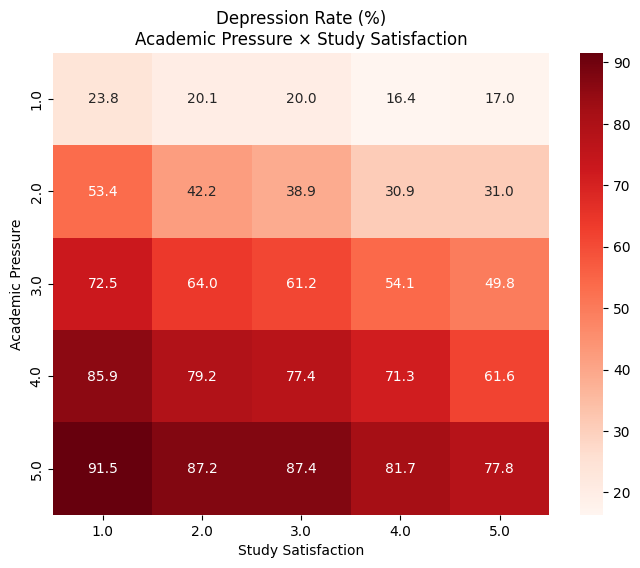

In [ ]:
tmp = student_df[['Academic Pressure','Study Satisfaction','Depression']].dropna()

# 교차 우울 비율 계산
summary = (
    tmp.groupby(['Academic Pressure','Study Satisfaction'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Academic Pressure × Study Satisfaction ===")
print(summary[['Academic Pressure','Study Satisfaction','Depression Rate (%)','count']])

# Pivot 형태 변환
pivot_table = summary.pivot(
    index='Academic Pressure',
    columns='Study Satisfaction',
    values='Depression Rate (%)'
)

print("\n=== Pivot Table (Depression %) ===")
print(pivot_table)

# Heatmap 시각화
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table,
            annot=True,
            fmt=".1f",
            cmap="Reds")
plt.title('Depression Rate (%)\nAcademic Pressure × Study Satisfaction')
plt.ylabel('Academic Pressure')
plt.xlabel('Study Satisfaction')
plt.show()

- Academic Pressure가 올라갈수록 모든 Satisfaction 수준에서 우울 비율이 급증한다.
- Study Satisfaction의 보호 효과는 존재하는가?
  - 같은 Presuure내에서 비교.
  - 예: Pressure = 3
| Satisfaction | 우울률   |
| ------------ | ----- |
| 1            | 72.5% |
| 5            | 49.8% |

=> 약 22%p 차이

만족도는 보호 효과가 있다.

---
- Pressure = 5
| Satisfaction | 우울률   |
| ------------ | ----- |
| 1            | 91.5% |
| 5            | 77.8% |

  - 보호 효과는 존재하지만, 77%도 이미 매우 높은 위험 수준.

=> 보호 요인이 압박을 완전히 상쇄하지 못한다.

### 2-3. Academic Pressure × Financial Stress 구조 탐색
학업 압박이 높을 때, 경제적 스트레스까지 높으면 위험이 더 증폭되는가?


=== Academic Pressure × Financial Stress ===
    Academic Pressure  Financial Stress  Depression Rate (%)  count
0                 1.0               1.0             7.222700   1163
1                 1.0               2.0            10.553633   1156
2                 1.0               3.0            19.935345    928
3                 1.0               4.0            28.053204    827
4                 1.0               5.0            42.600277    723
5                 2.0               1.0            14.989733    974
6                 2.0               2.0            20.982736    753
7                 2.0               3.0            38.612565    764
8                 2.0               4.0            48.370927    798
9                 2.0               5.0            65.607264    881
10                3.0               1.0            31.959508   1383
11                3.0               2.0            42.472666   1189
12                3.0               3.0            59.264600   1387
13

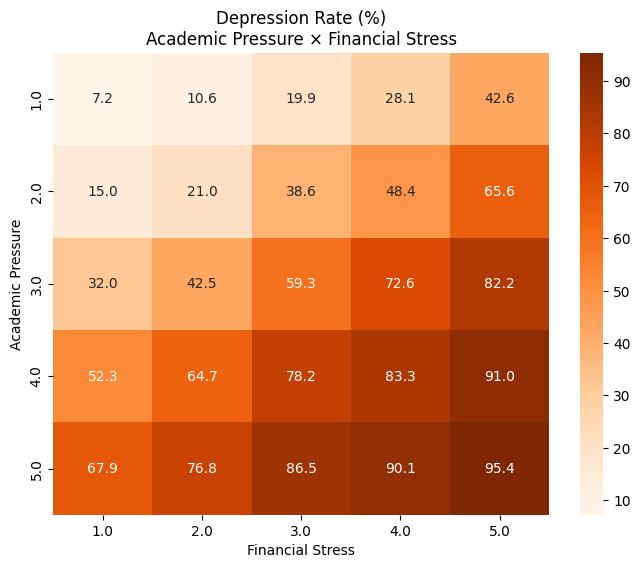

In [ ]:
tmp = student_df[['Academic Pressure','Financial Stress','Depression']].dropna()

# 교차 우울 비율 계산
summary = (
    tmp.groupby(['Academic Pressure','Financial Stress'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Academic Pressure × Financial Stress ===")
print(summary[['Academic Pressure','Financial Stress','Depression Rate (%)','count']])

# Pivot 변환
pivot_table = summary.pivot(
    index='Academic Pressure',
    columns='Financial Stress',
    values='Depression Rate (%)'
)

print("\n=== Pivot Table (Depression %) ===")
print(pivot_table)

# Heatmap 시각화
plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)
plt.title('Depression Rate (%)\nAcademic Pressure × Financial Stress')
plt.ylabel('Academic Pressure')
plt.xlabel('Financial Stress')
plt.show()

- Academic Pressure가 증가할수록, 모든 Financial Stress 수준에서 우울이 증가
- Financial Stress가 증가할수록, 모든 Academic Pressure 수준에서 우울이 증가

-> 두 변수 모두 독립적으로 강한 위험 요인임을 알 수 있음.

---
Pressure = 1일 때

| Financial 1 → 5 | 7% → 42% |

➡ 경제 스트레스만으로도 큰 상승

Pressure = 5일 때

| Financial 1 → 5 | 67% → 95% |

➡ 이미 고위험인데 더 증폭됨

---
Academic Pressure = 5

Financial Stress = 5

-> 우울률 95.4% (고위)

=> Academic Pressure와 Financial Stress는 독립적이며 상호 증폭적인 위험 요인으로 작용하며, 두 요인이 동시에 높을 경우 우울 위험은 구조적으로 급격히 증가한다.


### 2-4. Academic Pressure × Sleep Duration 구조 탐색
학업 압박이 높을 때, 수면 부족이 위험을 더 증폭시키는가?


=== Academic Pressure × Sleep Duration ===
    Academic Pressure     Sleep Duration  Depression Rate (%)  count
0                 1.0          5-6 hours            18.079096   1062
1                 1.0          7-8 hours            20.510774   1253
2                 1.0  Less than 5 hours            23.410853   1290
3                 1.0  More than 8 hours            15.088013   1193
4                 2.0          5-6 hours            36.192469    956
5                 2.0          7-8 hours            39.303001   1033
6                 2.0  Less than 5 hours            43.325143   1221
7                 2.0  More than 8 hours            29.344433    961
8                 3.0          5-6 hours            59.890110   1638
9                 3.0          7-8 hours            61.282772   2136
10                3.0  Less than 5 hours            65.318457   2151
11                3.0  More than 8 hours            51.733159   1529
12                4.0          5-6 hours            74.4645

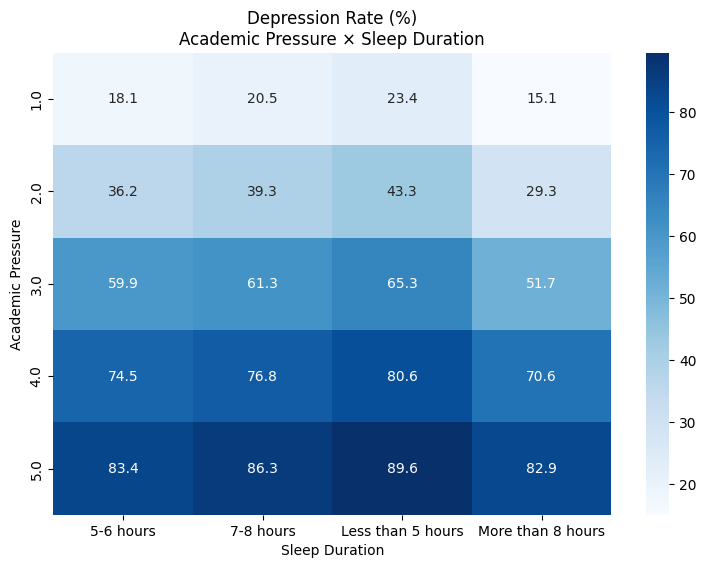

In [ ]:
tmp = student_df[['Academic Pressure','Sleep Duration','Depression']].dropna()

# 교차 우울 비율 계산
summary = (
    tmp.groupby(['Academic Pressure','Sleep Duration'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Academic Pressure × Sleep Duration ===")
print(summary[['Academic Pressure','Sleep Duration','Depression Rate (%)','count']])

# Pivot 변환
pivot_table = summary.pivot(
    index='Academic Pressure',
    columns='Sleep Duration',
    values='Depression Rate (%)'
)

print("\n=== Pivot Table (Depression %) ===")
print(pivot_table)

# Heatmap 시각화
plt.figure(figsize=(9,6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title('Depression Rate (%)\nAcademic Pressure × Sleep Duration')
plt.ylabel('Academic Pressure')
plt.xlabel('Sleep Duration')
plt.show()

- Academic Pressure가 증가할수록, 모든 수면 수준에서 우울 급증
- 같은 압박 수준내에서 수면시간은 보호 효과 존재.
  - 압박 = 5 : 보호 효과가 조금 줄어든다.

-> Sleep 은 압박이 매우 높으면 효과가 약화된다.

## 3. Working 집단 내부 구조 탐색

Working 집단에서 우울과 가장 강하게 관련된 요인은 무엇인가?

- Work Pressure
- Financial Stress
- Job Satisfaction
- Work/Study Hours
- Sleep Duration
- Dietary Habits
- Age

### 3-1. Working 내부 기본 위험 요인 랭킹

In [ ]:
def working_full_analysis(var, is_categorical=False):

    print("\n===================================================")
    print(f"Working 내부 분석: {var}")
    print("===================================================")

    tmp = working_df[[var,'Depression']].dropna()

    # -----------------------------
    # 수치형 변수
    # -----------------------------
    if not is_categorical:

        print("\n=== 평균 비교 ===")
        print(tmp.groupby('Depression')[var].mean())

        g0 = tmp[tmp['Depression']==0][var]
        g1 = tmp[tmp['Depression']==1][var]

        t_stat, p_val = stats.ttest_ind(g0, g1)

        pooled_std = np.sqrt(((g0.std()**2)+(g1.std()**2))/2)
        cohens_d = (g0.mean()-g1.mean()) / pooled_std

        print("\n=== t-test ===")
        print("t-statistic:", t_stat)
        print("p-value:", p_val)
        print("Cohen's d:", cohens_d)

        # 시각화
        plt.figure(figsize=(6,4))
        sns.boxplot(data=tmp, x='Depression', y=var)
        plt.title(f'{var} by Depression (Working)')
        plt.show()

    # -----------------------------
    # 범주형 변수
    # -----------------------------
    else:

        print("\n=== 분포(Count) ===")
        print(tmp[var].value_counts())

        summary = (
            tmp.groupby(var)['Depression']
            .agg(['mean','count'])
            .reset_index()
        )

        summary['Depression Rate (%)'] = summary['mean'] * 100

        print("\n=== 우울 비율(%) + N ===")
        print(summary[[var,'Depression Rate (%)','count']])

        # 카이제곱
        table = pd.crosstab(tmp[var], tmp['Depression'])
        chi2, p, dof, exp = chi2_contingency(table)

        n = table.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(table.shape)-1)))

        print("\n=== Chi-square test ===")
        print("Chi2:", chi2)
        print("p-value:", p)
        print("Cramér's V:", cramers_v)

        # 시각화
        plt.figure(figsize=(7,4))
        sns.barplot(data=summary, x=var, y='Depression Rate (%)')
        plt.title(f'Depression Rate by {var} (Working)')
        plt.xticks(rotation=45)
        plt.show()


Working 내부 분석: Work Pressure

=== 평균 비교 ===
Depression
0    2.908171
1    4.019421
Name: Work Pressure, dtype: float64

=== t-test ===
t-statistic: -74.48739117869752
p-value: 0.0
Cohen's d: -0.8591423657265631


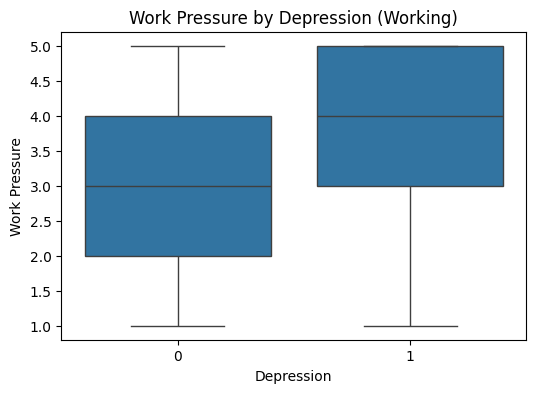


Working 내부 분석: Job Satisfaction

=== 평균 비교 ===
Depression
0    3.045822
1    2.174639
Name: Job Satisfaction, dtype: float64

=== t-test ===
t-statistic: 57.42176431217202
p-value: 0.0
Cohen's d: 0.6398362422342018


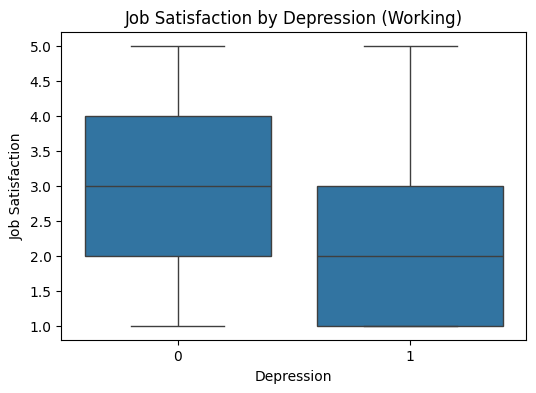


Working 내부 분석: Financial Stress

=== 평균 비교 ===
Depression
0    2.873153
1    3.831798
Name: Financial Stress, dtype: float64

=== t-test ===
t-statistic: -63.917658349940744
p-value: 0.0
Cohen's d: -0.7156535685012072


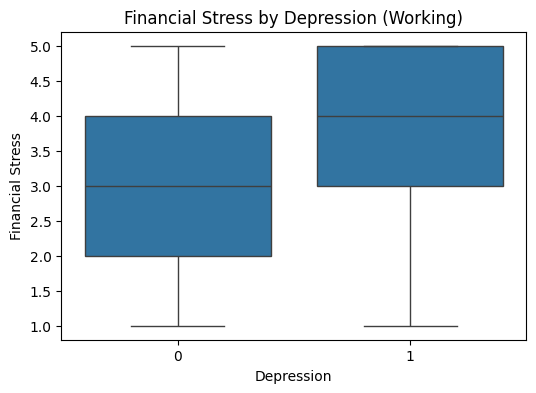


Working 내부 분석: Work/Study Hours

=== 평균 비교 ===
Depression
0    5.866884
1    7.844803
Name: Work/Study Hours, dtype: float64

=== t-test ===
t-statistic: -47.68048412924902
p-value: 0.0
Cohen's d: -0.5357800626241876


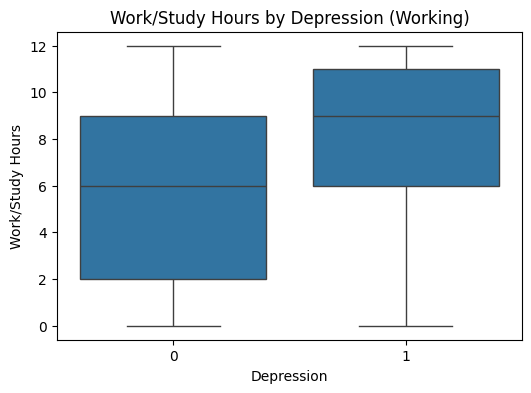


Working 내부 분석: Age

=== 평균 비교 ===
Depression
0    45.530552
1    26.717785
Name: Age, dtype: float64

=== t-test ===
t-statistic: 179.26244133864685
p-value: 0.0
Cohen's d: 2.03494585568791


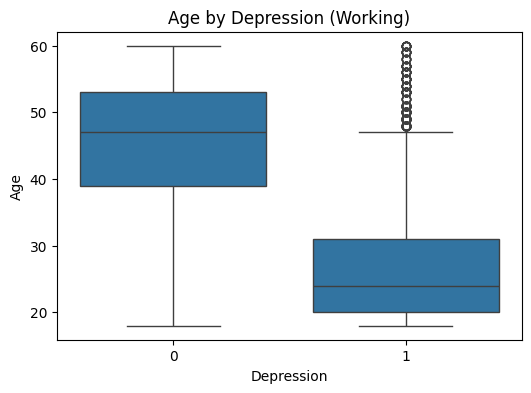

In [ ]:
# 수치형
numeric_vars = [
    'Work Pressure',
    'Job Satisfaction',
    'Financial Stress',
    'Work/Study Hours',
    'Age'
]

for var in numeric_vars:
    working_full_analysis(var, is_categorical=False)


Working 내부 분석: Sleep Duration

=== 분포(Count) ===
Sleep Duration
Less than 5 hours    30469
7-8 hours            29617
More than 8 hours    26679
5-6 hours            25958
Name: count, dtype: int64

=== 우울 비율(%) + N ===
      Sleep Duration  Depression Rate (%)  count
0          5-6 hours             6.953540  25958
1          7-8 hours             7.499071  29617
2  Less than 5 hours            12.274771  30469
3  More than 8 hours             5.476217  26679

=== Chi-square test ===
Chi2: 1009.4957708128079
p-value: 1.5674745598961925e-218
Cramér's V: 0.09463373532996547


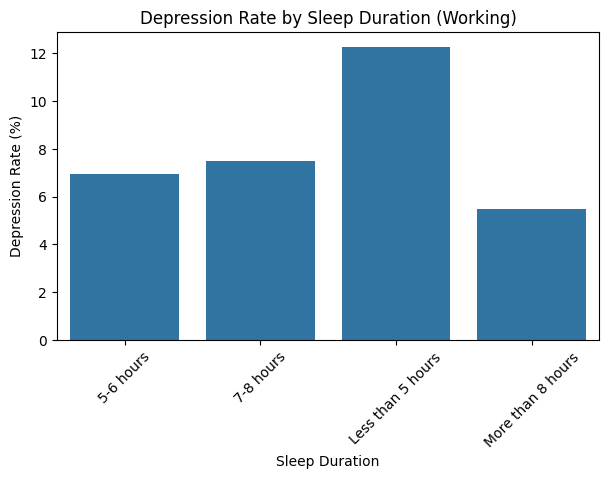


Working 내부 분석: Gender

=== 분포(Count) ===
Gender
Male      61876
Female    50847
Name: count, dtype: int64

=== 우울 비율(%) + N ===
   Gender  Depression Rate (%)  count
0  Female             7.961138  50847
1    Male             8.369966  61876

=== Chi-square test ===
Chi2: 6.152925904222132
p-value: 0.013119487718053248
Cramér's V: 0.007388130761065244


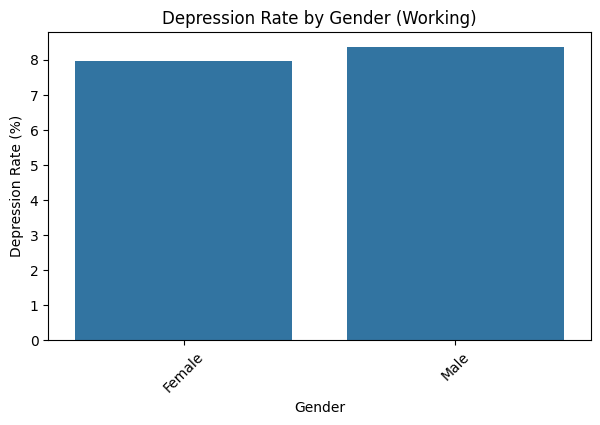


Working 내부 분석: Have you ever had suicidal thoughts ?

=== 분포(Count) ===
Have you ever had suicidal thoughts ?
No     60857
Yes    51866
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Have you ever had suicidal thoughts ?  Depression Rate (%)  count
0                                    No             1.771366  60857
1                                   Yes            15.711642  51866

=== Chi-square test ===
Chi2: 7238.577353560369
p-value: 0.0
Cramér's V: 0.25340801127843365


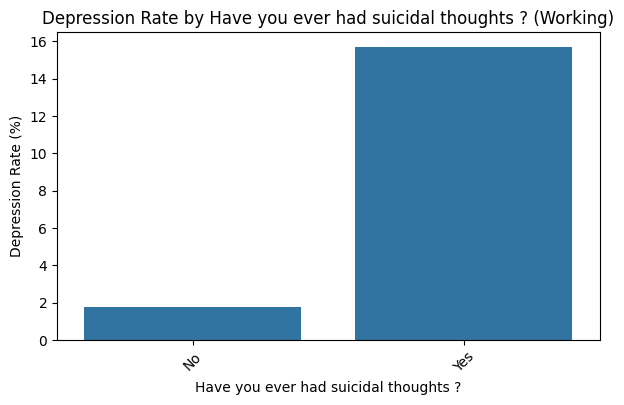


Working 내부 분석: Family History of Mental Illness

=== 분포(Count) ===
Family History of Mental Illness
Yes    56405
No     56318
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Family History of Mental Illness  Depression Rate (%)  count
0                               No             7.716893  56318
1                              Yes             8.653488  56405

=== Chi-square test ===
Chi2: 32.76798831628012
p-value: 1.0384089381205104e-08
Cramér's V: 0.017049773769523713


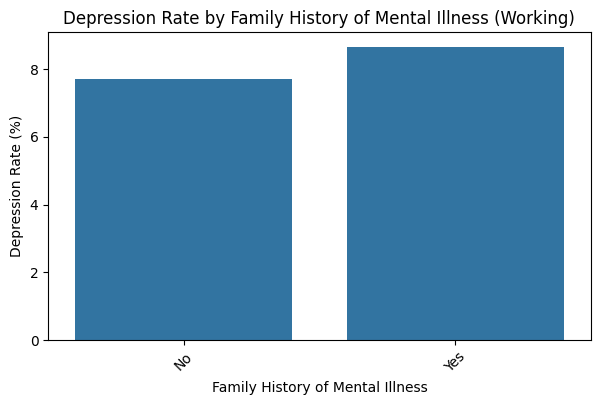


Working 내부 분석: Dietary Habits

=== 분포(Count) ===
Dietary Habits
Moderate     39756
Healthy      37075
Unhealthy    35892
Name: count, dtype: int64

=== 우울 비율(%) + N ===
  Dietary Habits  Depression Rate (%)  count
0        Healthy             4.873904  37075
1       Moderate             6.723513  39756
2      Unhealthy            13.225788  35892

=== Chi-square test ===
Chi2: 1867.312578094453
p-value: 0.0
Cramér's V: 0.12870702207020315


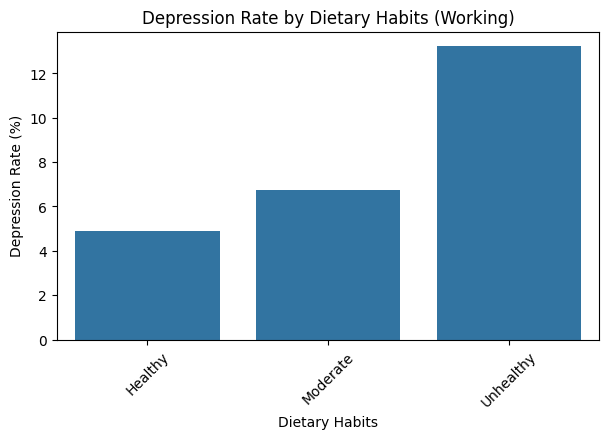

In [ ]:
# 범주형
categorical_vars = [
    'Sleep Duration',
    'Gender',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Dietary Habits'
]

for var in categorical_vars:
    working_full_analysis(var, is_categorical=True)

#### 결과해석(랭킹) - 효과 크기 기준
| 변수               | Cohen’s d | 해석     |
| ---------------- | --------- | ------ |
| Age              | **2.03**  | 매우 압도적 |
| Work Pressure    | 0.86      | 강함     |
| Financial Stress | 0.72      | 강함     |
| Job Satisfaction | 0.64      | 중~강    |
| Work Hours       | 0.54      | 중간     |

---
Age 효과 (d = 2.03)

우울 평균:

- 비우울: 45.5세

- 우울: 26.7세

-> Working 집단에서 우울은 거의 “젊은 층 현상”

Student는 전반적으로 고위험 구조였고
Working은 젊은 직장인 위험 구조다.

---

Student 구조:

압박 중심 + 경제 증폭형 구조
전체적으로 고위험 구조

Working 구조:

젊은 직장인 위험 집중형 구조

### 3-2. Work Pressure x Job Satisfaction
직무 압박이 높더라도 직무 만족도가 높으면 완충되는가?


=== Work Pressure × Job Satisfaction ===
    Work Pressure  Job Satisfaction  Depression Rate (%)  count
0             1.0               1.0             4.733879   3908
1             1.0               2.0             2.913236   4737
2             1.0               3.0             1.676403   3937
3             1.0               4.0             0.991240   4338
4             1.0               5.0             1.124081   4626
5             2.0               1.0             6.915226   4801
6             2.0               2.0             3.869850   5194
7             2.0               3.0             2.395704   4842
8             2.0               4.0             1.288427   4424
9             2.0               5.0             1.590106   5094
10            3.0               1.0            11.717949   3900
11            3.0               2.0             6.928314   4994
12            3.0               3.0             3.951562   4707
13            3.0               4.0             2.082288   398

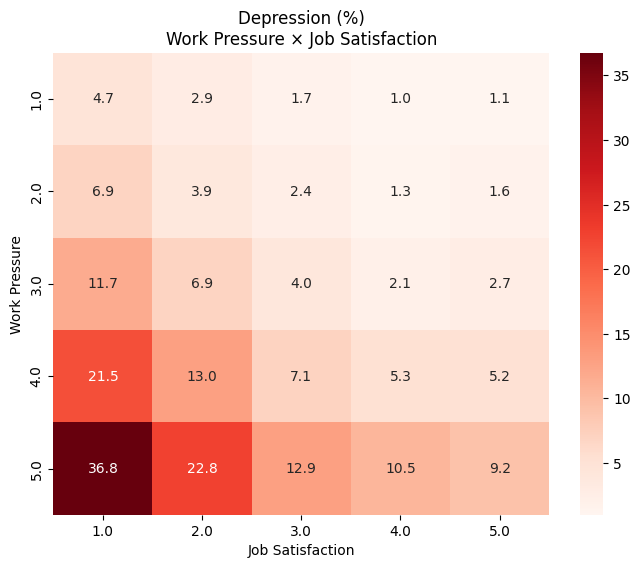

In [ ]:
tmp = working_df[['Work Pressure','Job Satisfaction','Depression']].dropna()

summary = (
    tmp.groupby(['Work Pressure','Job Satisfaction'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Work Pressure × Job Satisfaction ===")
print(summary[['Work Pressure','Job Satisfaction','Depression Rate (%)','count']])

pivot = summary.pivot(
    index='Work Pressure',
    columns='Job Satisfaction',
    values='Depression Rate (%)'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Depression (%)\nWork Pressure × Job Satisfaction")
plt.show()

- 완충 구조.
- 특히 높은 압박수준일때, 효과가 좋음.
  - pressure = 5
  | Satisfaction | 우울률   |
| ------------ | ----- |
| 1            | 36.7% |
| 5            | 9.2%  |

-> 약 27% 차이

=> 직무 압박이 높더라도 직무 만족도가 높으면 상당 부분 완충된다.

-> Student와 결정적으로 다른 부분.


### 3-3. Work Pressure × Financial Stress
직무 압박 + 경제적 스트레스의 이중 부담 구조 존재 여부 확인.


=== Work Pressure × Financial Stress ===
    Work Pressure  Financial Stress  Depression Rate (%)  count
0             1.0               1.0             0.725655   4272
1             1.0               2.0             1.173250   5114
2             1.0               3.0             1.701603   4055
3             1.0               4.0             2.654867   4068
4             1.0               5.0             5.372617   4039
5             2.0               1.0             1.039623   5098
6             2.0               2.0             1.497797   5675
7             2.0               3.0             2.516436   4411
8             2.0               4.0             3.735071   4605
9             2.0               5.0             8.015769   4566
10            3.0               1.0             2.073838   4388
11            3.0               2.0             2.393299   5014
12            3.0               3.0             4.444984   4117
13            3.0               4.0             6.173693   434

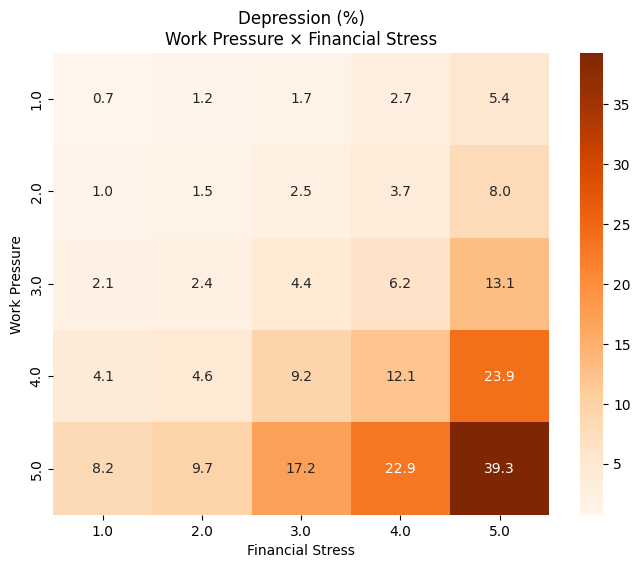

In [ ]:
tmp = working_df[['Work Pressure','Financial Stress','Depression']].dropna()

summary = (
    tmp.groupby(['Work Pressure','Financial Stress'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Work Pressure × Financial Stress ===")
print(summary[['Work Pressure','Financial Stress','Depression Rate (%)','count']])

pivot = summary.pivot(
    index='Work Pressure',
    columns='Financial Stress',
    values='Depression Rate (%)'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Depression (%)\nWork Pressure × Financial Stress")
plt.show()

- 이중 증폭 구조..

Pressure 5 & Financial 5

→ 39.3%

Pressure 1 & Financial 1

→ 0.7%

하지만,

Student는 이 조합이 95%까지 갔지만,

Working은 최대 39% 로 낮다.

-> Working은 압박 + 경제 스트레스가 증폭하긴 하지만, Student만큼 구조적 붕괴 수준은 아님

### 3-4. Age × Work Pressure
젊은 직장인 위험 구조가 Work Pressure와 결합해서 증폭되는가?

/tmp/ipykernel_2943/2643275367.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(['Age Group','Work Pressure'])['Depression']



=== Age × Work Pressure ===
   Age Group  Work Pressure  Depression Rate (%)  count
0      18-25            1.0            16.924477   1099
1      18-25            2.0            26.700252   1191
2      18-25            3.0            38.371240   1363
3      18-25            4.0            55.369928   1676
4      18-25            5.0            69.691992   2435
5      26-35            1.0             5.672761   2133
6      26-35            2.0             8.739924   2357
7      26-35            3.0            13.131313   2277
8      26-35            4.0            26.832248   2456
9      26-35            5.0            41.339001   2823
10     36-45            1.0             0.720288   6664
11     36-45            2.0             1.455738   7625
12     36-45            3.0             1.963513   6468
13     36-45            4.0             4.171705   6616
14     36-45            5.0             8.741547   6063
15     46-55            1.0             0.415963   7693
16     46-55       

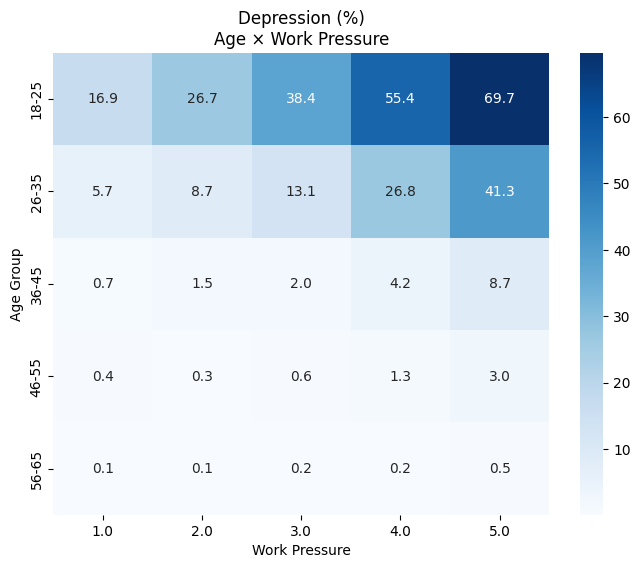

In [ ]:
# 연령 구간화
working_df['Age Group'] = pd.cut(
    working_df['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

tmp = working_df[['Age Group','Work Pressure','Depression']].dropna()

summary = (
    tmp.groupby(['Age Group','Work Pressure'])['Depression']
       .agg(['mean','count'])
       .reset_index()
)

summary['Depression Rate (%)'] = summary['mean'] * 100

print("\n=== Age × Work Pressure ===")
print(summary[['Age Group','Work Pressure','Depression Rate (%)','count']])

pivot = summary.pivot(
    index='Age Group',
    columns='Work Pressure',
    values='Depression Rate (%)'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Depression (%)\nAge × Work Pressure")
plt.show()

- working 집단은 '젊은 직장인 고위험 집중 구조'

# 2단계 : 집단별 구조 차이 통계 검증

집단 간 효과가 통계적으로 다른지 “단일 변수 수준”에서 검증

효과 차이 검정 (interaction test)

- 위에서 본 차이가 우연이 아닌지 통계적으로 증명하는 단계.

## 1. 집단 간 기본 위험 차이 검증

Student와 Working의 기본 우울 위험(유병률) 이 통계적으로 다른지 검증


=== Group별 우울 비율 ===
     Group  Depression Rate       N  Depression Rate (%)
0  Student         0.585499   27901            58.549873
1  Working         0.081836  112799             8.183583


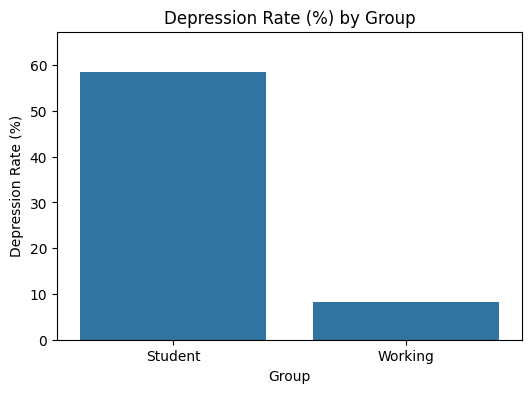


=== Chi-square test (Group × Depression) ===
Chi-square: 38157.58582778027
dof: 1
p-value: 0.0

Contingency table:
 Depression       0      1
Group                    
Student      11565  16336
Working     103568   9231

=== Effect Size (Student vs Working) ===
Risk(Student): 0.5854987276441704
Risk(Working): 0.08183583187794218
Risk Ratio (RR): 7.1545521589789605
Odds Ratio (OR): 15.848089908142844


In [ ]:
# 0) Group 컬럼 생성 (원본 train_df 기준)
df = train_df[['Working Professional or Student', 'Depression']].copy()
df = df.rename(columns={'Working Professional or Student':'Group'})
df['Group'] = df['Group'].replace({
    'Working Professional': 'Working',
    'Student': 'Student'
})

# 1) 집단별 우울 비율 + N
group_summary = (
    df.groupby('Group')['Depression']
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={'mean':'Depression Rate', 'count':'N'})
)
group_summary['Depression Rate (%)'] = group_summary['Depression Rate'] * 100

print("\n=== Group별 우울 비율 ===")
print(group_summary)

# 2) 시각화
plt.figure(figsize=(6,4))
sns.barplot(data=group_summary, x='Group', y='Depression Rate (%)')
plt.title('Depression Rate (%) by Group')
plt.ylim(0, group_summary['Depression Rate (%)'].max() * 1.15)
plt.show()

# 3) Chi-square test
cont = pd.crosstab(df['Group'], df['Depression'])
chi2, p, dof, exp = chi2_contingency(cont)

print("\n=== Chi-square test (Group × Depression) ===")
print("Chi-square:", chi2)
print("dof:", dof)
print("p-value:", p)
print("\nContingency table:\n", cont)

# 4) 효과 크기: RR / OR
# 테이블: Student/Working x (Depression=0/1)
# 안전하게 라벨로 접근
a = cont.loc['Student', 1]   # Student & Dep=1
b = cont.loc['Student', 0]   # Student & Dep=0
c = cont.loc['Working', 1]   # Working & Dep=1
d = cont.loc['Working', 0]   # Working & Dep=0

risk_student = a / (a + b)
risk_working = c / (c + d)
RR = risk_student / risk_working

odds_student = a / b
odds_working = c / d
OR = odds_student / odds_working

print("\n=== Effect Size (Student vs Working) ===")
print("Risk(Student):", risk_student)
print("Risk(Working):", risk_working)
print("Risk Ratio (RR):", RR)
print("Odds Ratio (OR):", OR)

1.집단별 우울 비율
- Student : 58.5%
- Working : 8.18%

-> 약 50%p 차이

=> 구조가 다를 가능성 시사.

---
2.Chi-square 결과

- χ² = 38157
- p-value = 0.0

표본이 크긴 하지만,
이 정도면 독립일 가능성은 사실상 0에 가깝다.

-> 집단과 우울은 강하게 연관되어 있다.

---
3.Effect Size

- Risk Ratio (RR) = 7.15

  - Student는 Working보다 약 7배 높은 위험 -> 엄청난 차이

- Odds Ratio (OR) = 15.85

  - Student의 우울 odds는 Working보다 약 16배 높다.

-> 집단이 다르면 구조가 다를 가능성

---
**Student 집단은 Working 집단에 비해 우울 위험이 약 7배(RR=7.15) 높았으며, 집단과 우울 간의 연관성은 통계적으로 매우 유의하였다(χ²=38157, p<.001). 이는 두 집단이 동일한 위험 구조를 공유한다고 보기 어렵다는 강력한 근거를 제공한다.**

#### **두 집단을 하나의 동일 모델로 설명하는 것은 부적절할 가능성이 높다 -> 집단 분리의 통계적 정당성 확보 완료**

## 2. 공통 요인의 집단별 효과 차이 검증

위 EDA에서 세웠던 가설들을 통계적으로 증명

### 2-1. Financial Stress 효과 차이 검정

Financial Stress는 두 집단 모두에서 강했기 때문에, '공통 요인'으로써 작용한다.

공통 요인이 집단마다 다르게 작동하는지 정량적으로 확인

In [ ]:
# 0) 분석용 데이터 생성
df2 = train_df[[
    'Depression',
    'Financial Stress',
    'Working Professional or Student'
]].copy()

df2 = df2.rename(columns={
    'Working Professional or Student': 'Group'
})

df2['Group'] = df2['Group'].replace({
    'Working Professional': 'Working',
    'Student': 'Student'
})

df2 = df2.dropna()

# 1) 로지스틱 회귀 (interaction 포함)
model = smf.logit(
    "Depression ~ Q('Financial Stress') * C(Group)",
    data=df2
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.333527
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:               140696
Model:                          Logit   Df Residuals:                   140692
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.2963
Time:                        10:07:18   Log-Likelihood:                -46926.
converged:                       True   LL-Null:                       -66687.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

Student에서 Finanacial Stress 효과
- Financial Stress = 0.5537 (p < .001)
  - Student에서 Financial Stress 1단계 증가할 때, log-odds가 0.5537 증가
  - np.exp(0.5537) ≈ 1.74

    -> Student는 Financial Stress 1단계 증가할 때, 약 1.74배 위험 증가

---
Working에서 Finanacial Stress 효과
- Financial Stress = 0.5537 + (-0.0300) = 0.5237
  - np.exp(0.5237) ≈ 1.69

    -> Working은 약 1.69배 증가

---
Interaction 항
- Financial Stress × Working = -0.0300
- p = 0.020

-> Financial Stress 효과가 Working에서 약간 감소한다.(= Financial Stress 효과는 Student에서 더 강하다.)

---
차이는 통계적으로 유의함을 확인함.

계수 차이는 0.03으로, 아주 큰 구조적 차이라고 보긴 어렵다.


### 2-2. Pressure 효과의 집단별 차이 검정
압박(Pressure)의 효과가 집단에 따라 통계적으로 다른가?

-> 두 집단 모두에 존재하는 Pressure 변수를 하나의 통합변수로 만들어 처리

In [ ]:
df3 = train_df[[
    'Depression',
    'Academic Pressure',
    'Work Pressure',
    'Working Professional or Student'
]].copy()

df3 = df3.rename(columns={'Working Professional or Student': 'Group'})
df3['Group'] = df3['Group'].replace({'Working Professional': 'Working', 'Student': 'Student'})

# Group 정리 (혹시 이상값 있으면 제거)
df3 = df3[df3['Group'].isin(['Student','Working'])].copy()

# Unified Pressure 생성
df3['Unified_Pressure'] = np.where(
    df3['Group'] == 'Student',
    df3['Academic Pressure'],
    df3['Work Pressure']
)

# 숫자형 강제 변환
df3['Unified_Pressure'] = pd.to_numeric(df3['Unified_Pressure'], errors='coerce')
df3['Depression'] = pd.to_numeric(df3['Depression'], errors='coerce')

# 결측 제거
df3 = df3.dropna(subset=['Depression','Unified_Pressure','Group']).copy()

# 혹시 Pressure가 1~5 범위 밖이면 제거(안전)
df3 = df3[df3['Unified_Pressure'].between(1,5)].copy()

print(df3.shape)
print(df3['Group'].value_counts())
print(df3['Unified_Pressure'].describe())

(140671, 5)
Group
Working    112779
Student     27892
Name: count, dtype: int64
count    140671.000000
mean          3.027376
std           1.401955
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: Unified_Pressure, dtype: float64


In [ ]:
# Working=1, Student=0
df3['Working'] = (df3['Group'] == 'Working').astype(int)

# 상호작용 항
df3['Pressure_x_Working'] = df3['Unified_Pressure'] * df3['Working']

X = df3[['Unified_Pressure', 'Working', 'Pressure_x_Working']]
X = sm.add_constant(X)
y = df3['Depression'].astype(int)

logit_model = sm.Logit(y, X).fit(disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:               140671
Model:                          Logit   Df Residuals:                   140667
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.3304
Time:                        10:07:19   Log-Likelihood:                -44640.
converged:                       True   LL-Null:                       -66662.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.1384      0.036    -59.309      0.000      -2.209      -2.068
Unified_Pressure       0.8191      0.011     72.543      0.000       0.797       0.841
Working             

In [ ]:
b_pressure = logit_model.params['Unified_Pressure']
b_inter = logit_model.params['Pressure_x_Working']

OR_student = np.exp(b_pressure)
OR_working = np.exp(b_pressure + b_inter)

print("OR (Student) per +1 pressure:", OR_student)
print("OR (Working) per +1 pressure:", OR_working)
print("Interaction (Working - Student) coef:", b_inter)
print("Interaction OR multiplier:", np.exp(b_inter))

OR (Student) per +1 pressure: 2.2685451042387834
OR (Working) per +1 pressure: 1.901012014402069
Interaction (Working - Student) coef: -0.17675231924188853
Interaction OR multiplier: 0.8379873121543946


모델: Depression∼Unified_Pressure+Working+Pressure×Working
- 기준 집단 = Student

---
Student 에서 Pressure 효과
- Unified_Pressure = 0.8191 (p < .001)
- OR 계산 -> 2.27

-> Student는 압박 1단계 증가 시 우울 odds가 약 2.27배 증가 (매우 강한 효과)

---
Working에서 Pressure 효과
- 0.8191 + (-0.1768) = 0.6423
- OR -> 0.90

-> Working은 압박 1단계 증가 시 약 1.90배 증가

---
Interaction 항
- Pressure_x_Working = -0.1768
- p < .001

-> 압박 효과는 Working에서 유의하게 감소한다.

-> 압박은 Student에서 더 강하게 작동한다. (압박 효과 강도 차이 약 19% 감소) => 이건 통계적으로 매우 유의하고, 실질적으로도 의미 있는 차이임.

---
**압박(Pressure)의 우울 위험 효과는 Student 집단에서 Working 집단보다 유의하게 더 강하게 나타났다 (interaction β = -0.1768, p < .001). Student에서는 압박 1단계 증가 시 우울 odds가 약 2.27배 증가한 반면, Working에서는 1.90배 증가하였다.**

### 2-3. 보호 요인의 집단별 효과 차이 검정

Satisfaction

In [ ]:
df4 = train_df[[
    'Depression',
    'Study Satisfaction',
    'Job Satisfaction',
    'Working Professional or Student'
]].copy()

df4 = df4.rename(columns={'Working Professional or Student':'Group'})
df4['Group'] = df4['Group'].replace({'Working Professional':'Working', 'Student':'Student'})
df4 = df4[df4['Group'].isin(['Student','Working'])].copy()

# -----------------------------
# 2) Unified Satisfaction 생성
# -----------------------------
df4['Unified_Satisfaction'] = np.where(
    df4['Group']=='Student',
    df4['Study Satisfaction'],
    df4['Job Satisfaction']
)

df4['Unified_Satisfaction'] = pd.to_numeric(df4['Unified_Satisfaction'], errors='coerce')
df4['Depression'] = pd.to_numeric(df4['Depression'], errors='coerce')

df4 = df4.dropna(subset=['Depression','Unified_Satisfaction','Group']).copy()

# 만족도는 1~5만 사용 (안전)
df4 = df4[df4['Unified_Satisfaction'].between(1,5)].copy()

# -----------------------------
# 3) interaction 로지스틱
# -----------------------------
df4['Working'] = (df4['Group']=='Working').astype(int)
df4['Sat_x_Working'] = df4['Unified_Satisfaction'] * df4['Working']

X = df4[['Unified_Satisfaction','Working','Sat_x_Working']]
X = sm.add_constant(X)
y = df4['Depression'].astype(int)

m_sat = sm.Logit(y, X).fit(disp=False)
print(m_sat.summary())

# -----------------------------
# 4) OR로 해석하기
# -----------------------------
b_sat = m_sat.params['Unified_Satisfaction']
b_int = m_sat.params['Sat_x_Working']

print("\n=== OR (per +1 satisfaction) ===")
print("Student OR:", np.exp(b_sat))
print("Working OR:", np.exp(b_sat + b_int))
print("Interaction multiplier (Working vs Student):", np.exp(b_int))

                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:               140673
Model:                          Logit   Df Residuals:                   140669
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                  0.2684
Time:                        10:07:21   Log-Likelihood:                -48770.
converged:                       True   LL-Null:                       -66663.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1074      0.030     36.472      0.000       1.048       1.167
Unified_Satisfaction    -0.2553      0.009    -27.827      0.000      -0.273      -0.237
Working     

모델: Depression∼Satisfaction+Working+Satisfaction×Working
- 기준집단 = Student

---
Student에서 Satisfaction 효과
- Unified_Satisfaction = -0.2553
- OR : 0.775

-> Student는 만족도 1단계 증가 시 우울 odds가 약 22.5% 감소

---
Working에서 Satisfaction 효과
- -0.2553 + (-0.2231) = -0.4784
- OR : 0.620

-> Working은 만족도 1단계 증가 시 우울 odds가 약 38% 감소

---
Interaction 항
- Sat_x_Working = -0.2231
- p < .001
- OR : 0.80

-> 만족도의 보호 효과는 Working에서 Student보다 20% 더 강하다.'

---

**=> “Student와 Working은 구조적으로 다르다”-> 통계적으로 증명됨.**



# 3단계 : 다변량 모델로 구조 검증

각 집단에서 어떤 요인이 독립적으로 우울에 영향을 미치는가?

## 1. Student 다변량 모델 설계

In [ ]:
student_cols = [
    'Depression',
    'Age',
    'Gender',
    'Academic Pressure',
    'Study Satisfaction',
    'Financial Stress',
    'Work/Study Hours',
    'CGPA',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Sleep Duration',
    'Working Professional or Student'
]

student_df = train_df[student_cols].copy()
student_df = student_df[student_df['Working Professional or Student'] == 'Student'].copy()

print("Student raw shape:", student_df.shape)
print("Target distribution:\n", student_df['Depression'].value_counts())

Student raw shape: (27901, 13)
Target distribution:
 Depression
1    16336
0    11565
Name: count, dtype: int64


In [ ]:
## Category Cleaning
"""
Diet 3개만
Sleep 4개만 (원하면 제거 가능)
Pressure/Satisfaction/Stress/CGPA는 1~5 / 0~10 범위 sanity check
"""

valid_diet = ['Healthy', 'Moderate', 'Unhealthy']
valid_sleep = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']

student_df = student_df[student_df['Dietary Habits'].isin(valid_diet)].copy()
student_df = student_df[student_df['Sleep Duration'].isin(valid_sleep)].copy()

# 숫자형
num_cols = ['Age','Academic Pressure','Study Satisfaction','Financial Stress','Work/Study Hours','CGPA']
for c in num_cols:
    student_df[c] = pd.to_numeric(student_df[c], errors='coerce')

# 결측 제거
student_df = student_df.dropna(subset=[
    'Depression','Age','Gender','Academic Pressure','Study Satisfaction','Financial Stress',
    'Work/Study Hours','CGPA','Dietary Habits','Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness','Sleep Duration'
]).copy()

print("Student cleaned shape:", student_df.shape)
print("Target distribution(cleaned):\n", student_df['Depression'].value_counts())

Student cleaned shape: (27854, 13)
Target distribution(cleaned):
 Depression
1    16311
0    11543
Name: count, dtype: int64


In [ ]:
## One-hot Encoding

cat_cols = [
    'Gender',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Sleep Duration'
]

model_df = pd.get_dummies(student_df.drop(columns=['Working Professional or Student']), columns=cat_cols, drop_first=True)

X = model_df.drop('Depression', axis=1)
y = model_df['Depression'].astype(int)

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (27854, 14) y shape: (27854,)


In [ ]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [ ]:
# Logistic Regression
clf = LogisticRegression(max_iter=3000)
clf.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': clf.coef_[0]
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\n=== Student Multivariable Logistic: Top 30 (abs) ===")
print(coef_df.head(30))


=== Student Multivariable Logistic: Top 30 (abs) ===
                                      Feature  Coefficient       Abs
9   Have you ever had suicidal thoughts ?_Yes     1.210456  1.210456
1                           Academic Pressure     1.150463  1.150463
3                            Financial Stress     0.806650  0.806650
0                                         Age    -0.537040  0.537040
8                    Dietary Habits_Unhealthy     0.528044  0.528044
4                            Work/Study Hours     0.423956  0.423956
2                          Study Satisfaction    -0.350857  0.350857
7                     Dietary Habits_Moderate     0.231075  0.231075
12           Sleep Duration_Less than 5 hours     0.192645  0.192645
10       Family History of Mental Illness_Yes     0.139433  0.139433
13           Sleep Duration_More than 8 hours    -0.097949  0.097949
5                                        CGPA     0.075356  0.075356
11                   Sleep Duration_7-8 hours    

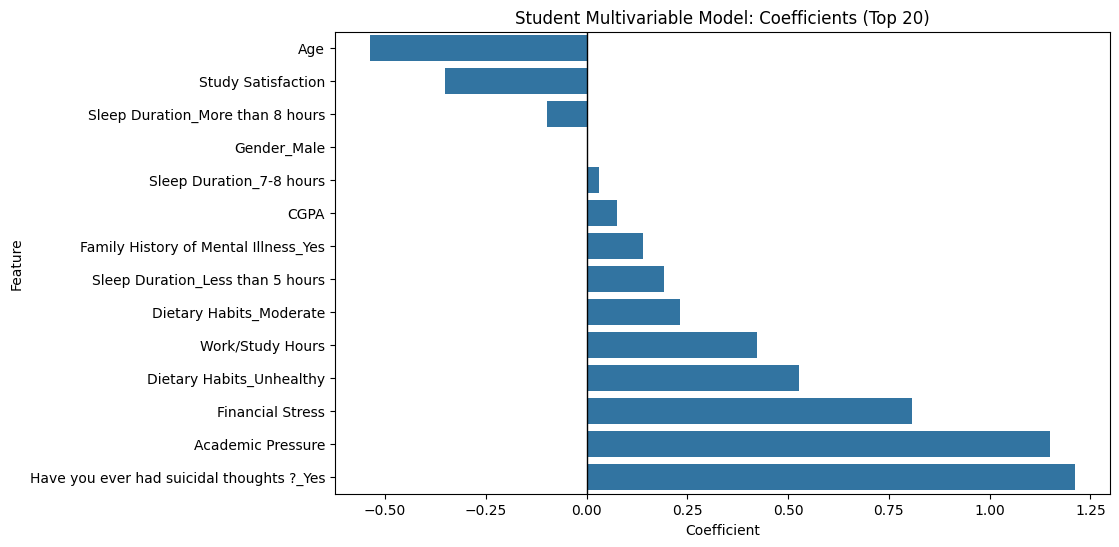

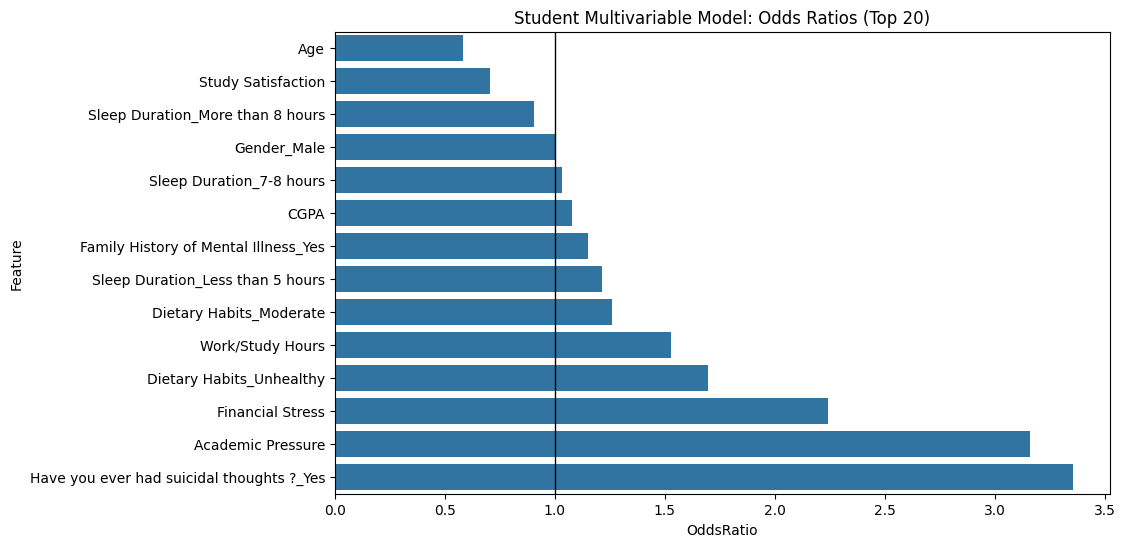

In [ ]:
# Odds Ratio 변환.
coef_df['OddsRatio'] = np.exp(coef_df['Coefficient'])

topk = 20
plot_df = coef_df.head(topk).sort_values('Coefficient')

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df, x='Coefficient', y='Feature')
plt.title(f'Student Multivariable Model: Coefficients (Top {topk})')
plt.axvline(0, color='black', linewidth=1)
plt.show()

# OR plot
plot_or = coef_df.head(topk).sort_values('OddsRatio')

plt.figure(figsize=(10,6))
sns.barplot(data=plot_or, x='OddsRatio', y='Feature')
plt.title(f'Student Multivariable Model: Odds Ratios (Top {topk})')
plt.axvline(1, color='black', linewidth=1)
plt.show()

### 결과 해석

표본:
- N = 27,854
- 우울 비율 ≈ 58.5%

---
강한 독립 요인순서...
1. 자살 생각 경험
- Coef ≈ 1.21
- OR ≈ 3.35

-> 자살 생각 경험자는 우울 odds가 3.3배

2. Adacemic Pressure
- Coef ≈ 1.15
- OR ≈ 3.16

-> 압박 1단계 증가 시 우울 odds 3배 이상 (2단계에서 본 것보다 더 강하게 나온다.)

3. Financial Stress
- Coef ≈ 0.81
- OR ≈ 2.24

-> 재정 스트레스도 매우 강한 독립 위험 요인.

4. Age (음수)
- Coef ≈ -0.54
- OR ≈ 0.58

-> 나이 많을수록 위험 감소

→ 어린 Student일수록 취약

5. 기타 등등..
- 식습관, 과도한 학습시간도 독맂 요인.

---
보호 요인 - Study Satisfaction
- Coef ≈ -0.35
- OR ≈ 0.70

-> 만족도 1단계 증가 시 우울 30% 감소 (보호 요인이긴 하나, 압박(OR 3.16)을 상쇄할 수준은 아님.)

---
- Gender → 거의 0
- Sleep 7-8h → 거의 0
- CGPA → 매우 약함

-> 성별/성적은 구조 핵심이 아니다.

위험 요인 강도 순서:

1. Suicidal thoughts
2. Academic Pressure
3. Financial Stress
4. Age(젊을수록 위험)
5. Unhealthy diet
6. Work hours

보호요인 : Study Satisfaction (중간 level)

---
**=> Student 집단은 학업 압박과 재정 스트레스가 중심이 되는 위험 구조이며, 만족도는 보호 요인이지만 위험 요인을 완전히 상쇄하지는 못한다.**

## 2. Working 다변량 모델 설계

어떤 요인이 독립적으로 영향을 미치는지?
그리고 Working 집단은 Student와 '다른 구조'를 가지는지?

In [ ]:
working_cols = [
    'Depression',
    'Age',
    'Gender',
    'Work Pressure',
    'Job Satisfaction',
    'Financial Stress',
    'Work/Study Hours',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Sleep Duration',
    'Working Professional or Student'
]

working_df = train_df[working_cols].copy()
working_df = working_df[working_df['Working Professional or Student'] == 'Working Professional'].copy()

print("Working raw shape:", working_df.shape)
print("Target distribution:\n", working_df['Depression'].value_counts())

Working raw shape: (112799, 12)
Target distribution:
 Depression
0    103568
1      9231
Name: count, dtype: int64


In [ ]:
## 전처리

valid_diet = ['Healthy', 'Moderate', 'Unhealthy']
valid_sleep = ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours']

working_df = working_df[working_df['Dietary Habits'].isin(valid_diet)].copy()
working_df = working_df[working_df['Sleep Duration'].isin(valid_sleep)].copy()

num_cols = ['Age','Work Pressure','Job Satisfaction','Financial Stress','Work/Study Hours']
for c in num_cols:
    working_df[c] = pd.to_numeric(working_df[c], errors='coerce')

working_df = working_df.dropna(subset=[
    'Depression','Age','Gender','Work Pressure','Job Satisfaction',
    'Financial Stress','Work/Study Hours','Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness','Sleep Duration'
]).copy()

print("Working cleaned shape:", working_df.shape)
print("Target distribution(cleaned):\n", working_df['Depression'].value_counts())

Working cleaned shape: (112697, 12)
Target distribution(cleaned):
 Depression
0    103482
1      9215
Name: count, dtype: int64


In [ ]:
cat_cols = [
    'Gender',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness',
    'Sleep Duration'
]

model_df_w = pd.get_dummies(
    working_df.drop(columns=['Working Professional or Student']),
    columns=cat_cols,
    drop_first=True
)

X_w = model_df_w.drop('Depression', axis=1)
y_w = model_df_w['Depression'].astype(int)

print("X_w shape:", X_w.shape)

X_w shape: (112697, 13)


In [ ]:
# split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42, stratify=y_w
)

# scale
scaler_w = StandardScaler()
X_train_w_sc = scaler_w.fit_transform(X_train_w)
X_test_w_sc = scaler_w.transform(X_test_w)

In [ ]:
# logistic
clf_w = LogisticRegression(max_iter=3000)
clf_w.fit(X_train_w_sc, y_train_w)

coef_df_w = pd.DataFrame({
    'Feature': X_w.columns,
    'Coefficient': clf_w.coef_[0]
})
coef_df_w['Abs'] = coef_df_w['Coefficient'].abs()
coef_df_w = coef_df_w.sort_values('Abs', ascending=False)

print("\n=== Working Multivariable Logistic: Top 30 (abs) ===")
print(coef_df_w.head(30))


=== Working Multivariable Logistic: Top 30 (abs) ===
                                      Feature  Coefficient       Abs
0                                         Age    -1.960491  1.960491
8   Have you ever had suicidal thoughts ?_Yes     1.182238  1.182238
1                               Work Pressure     0.882577  0.882577
3                            Financial Stress     0.769306  0.769306
2                            Job Satisfaction    -0.766259  0.766259
4                            Work/Study Hours     0.557877  0.557877
7                    Dietary Habits_Unhealthy     0.455926  0.455926
11           Sleep Duration_Less than 5 hours     0.216932  0.216932
6                     Dietary Habits_Moderate     0.204877  0.204877
12           Sleep Duration_More than 8 hours    -0.169502  0.169502
9        Family History of Mental Illness_Yes     0.073389  0.073389
10                   Sleep Duration_7-8 hours    -0.019737  0.019737
5                                 Gender_Male    

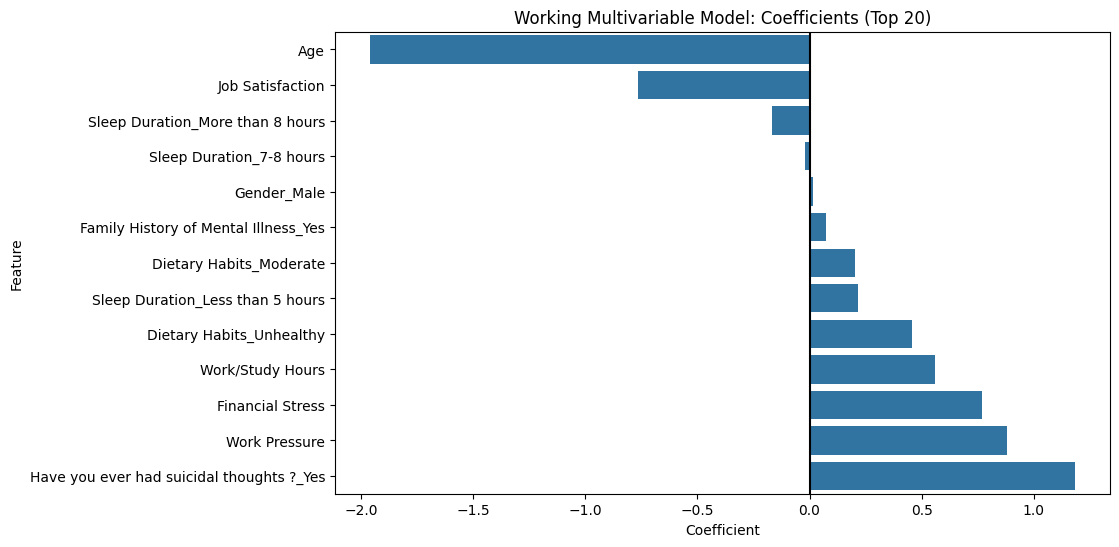

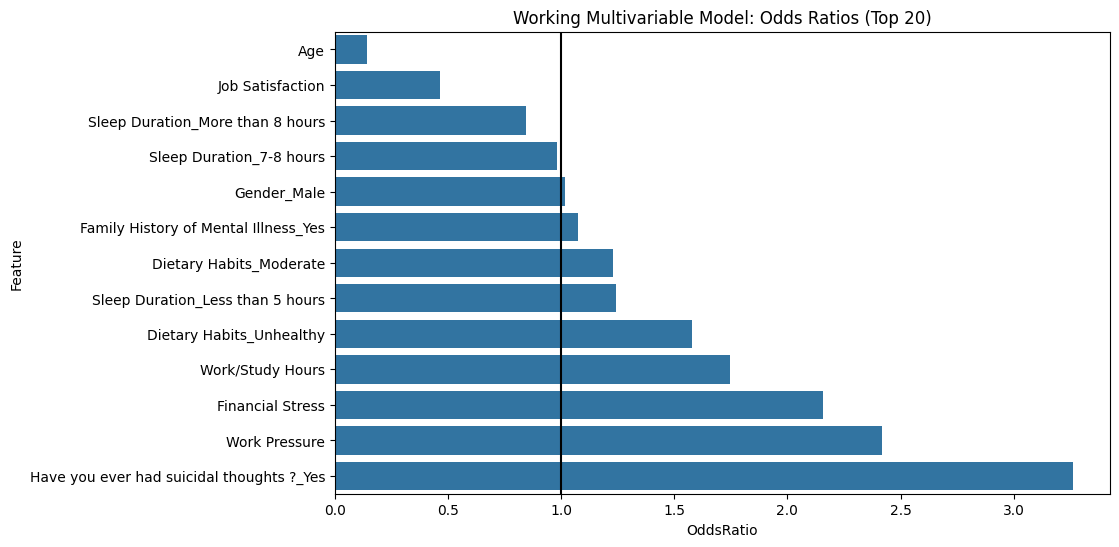

In [ ]:
coef_df_w['OddsRatio'] = np.exp(coef_df_w['Coefficient'])

topk = 20
plot_df_w = coef_df_w.head(topk).sort_values('Coefficient')

plt.figure(figsize=(10,6))
sns.barplot(data=plot_df_w, x='Coefficient', y='Feature')
plt.title(f'Working Multivariable Model: Coefficients (Top {topk})')
plt.axvline(0, color='black')
plt.show()

plot_or_w = coef_df_w.head(topk).sort_values('OddsRatio')

plt.figure(figsize=(10,6))
sns.barplot(data=plot_or_w, x='OddsRatio', y='Feature')
plt.title(f'Working Multivariable Model: Odds Ratios (Top {topk})')
plt.axvline(1, color='black')
plt.show()

### 결과 해석
Working 표본
- N ≈ 112,697
- 우울 비율 ≈ 8.2%

---
가장 강한 요인 순으로..
1. Age
- Coef ≈ -1.96
- OR ≈ 0.14

-> 나이가 많을수록 우울 위험 급감

-> Working 구조에서 Age가 압도적
(Student와 다른 부분.)

2. Suicidal Thoughts
- OR ≈ 3.26

-> Student와 유사하게 강함

-> 공통 초고위험 요인

3. Work Pressure
- OR ≈ 2.42

-> 압박은 여전히 강하다

-> 하지만 Student(OR 3.16)보다 약하다.

4. Financial Stress
- OR ≈ 2.16

-> Student와 유사하게 강한 요인

5. Job Satisfaction
- Coef ≈ -0.77
- OR ≈ 0.46

-> 만족도 1단계 증가 시 위험 54% 감소
-> Student보다 훨씬 강한 보호 효과

6. 기타..
- 근무 시간, 식습관 O

---
영향 거의 없음.
- Gender 거의 0
- Sleep 거의 미미
- Family History 약함



## 3. 집단 간 구조 비교

| 요인                | Student         | Working            | 구조 차이        |
| ----------------- | --------------- | ------------------ | ------------ |
| Age               | 중간 (-0.54)      | 매우 강함 (-1.96)      | Working 중심   |
| Pressure          | 매우 강함 (OR 3.16) | 강함 (OR 2.42)       | Student 더 민감 |
| Satisfaction      | 보호 (OR 0.70)    | 매우 강한 보호 (OR 0.46) | Working 더 중요 |
| Financial         | 강함              | 강함                 | 공통 위험        |
| Suicidal Thoughts | 매우 강함           | 매우 강함              | 공통 초위험       |
| Diet              | 중간              | 중간                 | 약한 공통        |
| Gender            | 무의미             | 무의미                | 구조 아님        |
